In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

## Read in data & define functions

In [9]:
# Read in our subject data
SST = pd.read_csv('../data/csv_files/udlstudy.csv') # SetSize Table
pd.set_option('display.max_columns', None) #lets us view all of the columns at once 
display(SST.tail())

#function to unpack repeated target value from series
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['TargetAngle'] == N_minus_targ),'TrialNumber'] + 1
    N_df = group.loc[(group['TrialNumber'].isin(N_trial_num))]
    return N_df

,Experiment_Name,Prolific_ID,Study_ID,Session_ID,Repeated_Target,StartTime,TrialNumber,TargetAngle,Probe,CursorFB,Rotation,HandAngle,RT,MT,SearchTime,ReachFB
45815,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.25.677,1576,60,0,online_fb,0,57.693516,525,17,1624,good_reach
45816,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.28.230,1577,60,0,online_fb,0,51.430500,729,50,1657,good_reach
45817,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.30.865,1578,60,1,no_fb,0,62.844231,589,51,1877,good_reach
45818,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.33.64,1579,60,0,online_fb,0,68.652744,816,78,1188,good_reach
45819,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.36.129,1580,60,0,online_fb,0,55.295435,822,67,2044,good_reach


# Data Wrangling 

In [10]:
epochs = {
    'fb_practice'    :    (1,   8),      # Baseline reaching
    'repulse'        :    (17,   716),   # Main experiment block
    'repulse_clean'  :    (117,   716),   # For bias correction
    'udl'            :    (717,  1580), # Main experiment block
}

###Excluded Participants###
#Incorrect Target file participants (see notes)
p_list1 = ['697a7935484b9b22a05fe3b6', '6980899c7847724b431b38ac', '665a9ddb536966183500a7b1', '698138565bd9d4728a0a2e04', '669f349c50e94fd78b7c3b66', '698087b7749205156fad2839']
participant_filter = ~SST['Prolific_ID'].isin(set(p_list1))
subj_ids = SST.loc[participant_filter]['Prolific_ID'].unique()

#Participants with 60 deg repeated target (hardcoded for now)
p_list2 = ['6138d26ce6302b626fcf805c','68eeef06a1e6a76c343f8572','698078075d3326e1b30bd1c3','69808dc8bf8f451969f94eeb',
           '6980b37761737090ad122e6f', '6980c5902273a0acf918ced1', '6980e65cf91af20e6f20fffb', '698108404d737ae8dbb46561',
           '69813905f71215f35bace3c3', '69826a7388a6fddffdc8d757', '6989baec35fa286279b29ca5', '698b57a46bf6a0eee98c0c04']

#Make a copy of modified dataframe and assign to new dataframe
SST2 = SST.loc[participant_filter].copy()

mean_angs = SST2.loc[(SST2['TrialNumber'] >= epochs['repulse_clean'][0]) & (SST2['TrialNumber'] <= epochs['repulse_clean'][1])].groupby('Prolific_ID').apply(find_rep)

# Calculate hand angle relative to target. 
RadError = np.deg2rad(SST2['HandAngle'] - SST2['TargetAngle'])
SST2['AngleError'] = np.rad2deg(np.arctan2(np.sin(RadError), np.cos(RadError)))

bias_subset = (
    SST2.loc[(SST2['TrialNumber'] >= epochs['repulse_clean'][0]) & (SST2['TrialNumber'] <= epochs['repulse_clean'][1]) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60)]
    .groupby(['Prolific_ID', 'TargetAngle'], as_index=False)['AngleError']
    .mean()
    .rename(columns={'AngleError': 'Bias'})
)

SST2 = SST2.merge(bias_subset, on=['Prolific_ID', 'TargetAngle'], how='left')

# Correct for target-level reach biases by subtraction of mean hand angle to a target
RadCorrDiff = np.deg2rad(SST2['AngleError'] - SST2['Bias'])
SST2['AngleError_Corrected'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

#Shift hand angle and target angle by 90 deg for participants in p_list2 to align with other participants
mask = SST2['Prolific_ID'].isin(set(p_list2))

TA_rad_shift = np.deg2rad(SST2.loc[mask]['TargetAngle']) + np.deg2rad(90)
SST2.loc[mask,'TargetAngle'] = (np.rad2deg(np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))) % 360).round()

# Get target location difference values
SST2['TargetAngleN1Diff'] = pd.Series(pd.NA, index=SST2.index, dtype='Float64')
# Get target location difference values for repulsive block first
# Notes: 1) multiply by -1 because we want positive to be clockwise. 2) add one to starting index 
# because we want the first trial for every block to be NA
mask = (SST2['TrialNumber'] >= epochs['repulse'][0] + 1) & (SST2['TrialNumber'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(SST2.loc[mask].groupby('Prolific_ID')['TargetAngle'].diff(periods=1))*-1
SST2.loc[mask,'TargetAngleN1Diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

# Get target location difference values for UDL block
mask = (SST2['TrialNumber'] >= epochs['udl'][0] + 1) & (SST2['TrialNumber'] <= epochs['udl'][1])
RadTAN1diff_udl = np.deg2rad(SST2.loc[mask].groupby('Prolific_ID')['TargetAngle'].diff(periods=1))*-1
SST2.loc[mask,'TargetAngleN1Diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_udl), np.cos(RadTAN1diff_udl)))

#round
SST2['TargetAngleN1Diff'] = SST2['TargetAngleN1Diff'].round().astype('Int64')
SST2 

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_59314/1149426614.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_angs = SST2.loc[(SST2['TrialNumber'] >= epochs['repulse_clean'][0]) & (SST2['TrialNumber'] <= epochs['repulse_clean'][1])].groupby('Prolific_ID').apply(find_rep)


,Experiment_Name,Prolific_ID,Study_ID,Session_ID,Repeated_Target,StartTime,TrialNumber,TargetAngle,Probe,CursorFB,Rotation,HandAngle,RT,MT,SearchTime,ReachFB,AngleError,Bias,AngleError_Corrected,TargetAngleN1Diff
0,udlr_study,6138d26ce6302b626fcf805c,69ffa0c003e14a5a926cbde6,6a024eb2e1250c6bff8a825a,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/11/2026 16:1.30.484,1,60,0,online_fb,0,338.806682,518,25,4539,good_reach,8.806682,4.151126,4.655556,<NA>
1,udlr_study,6138d26ce6302b626fcf805c,69ffa0c003e14a5a926cbde6,6a024eb2e1250c6bff8a825a,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/11/2026 16:1.33.921,2,240,0,online_fb,0,162.415278,479,39,1623,good_reach,12.415278,-2.591683,15.006960,<NA>
2,udlr_study,6138d26ce6302b626fcf805c,69ffa0c003e14a5a926cbde6,6a024eb2e1250c6bff8a825a,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/11/2026 16:1.39.468,3,120,0,online_fb,0,30.020988,506,24,1370,good_reach,0.020988,9.002534,-8.981545,<NA>
3,udlr_study,6138d26ce6302b626fcf805c,69ffa0c003e14a5a926cbde6,6a024eb2e1250c6bff8a825a,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/11/2026 16:1.42.26,4,90,0,online_fb,0,355.673952,492,25,1932,good_reach,-4.326048,1.494759,-5.820807,<NA>
4,udlr_study,6138d26ce6302b626fcf805c,69ffa0c003e14a5a926cbde6,6a024eb2e1250c6bff8a825a,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/11/2026 16:1.44.931,5,180,0,online_fb,0,86.664120,502,13,2267,good_reach,-3.335880,-0.118647,-3.217233,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36335,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.25.677,1576,150,0,online_fb,0,57.693516,525,17,1624,good_reach,-2.306484,5.304220,-7.610704,0
36336,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.28.230,1577,150,0,online_fb,0,51.430500,729,50,1657,good_reach,-8.569500,5.304220,-13.873720,0
36337,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.30.865,1578,150,1,no_fb,0,62.844231,589,51,1877,good_reach,2.844231,5.304220,-2.459988,0
36338,udlr_study,6980b37761737090ad122e6f,69ffa0c003e14a5a926cbde6,6a024ec3c62e2da42b7d5a71,"[60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 6...",5/12/2026 2:24.33.64,1579,150,0,online_fb,0,68.652744,816,78,1188,good_reach,8.652744,5.304220,3.348525,0


# Plot bias across all random phase trials

Text(0, 0.5, 'Corrected Bias')

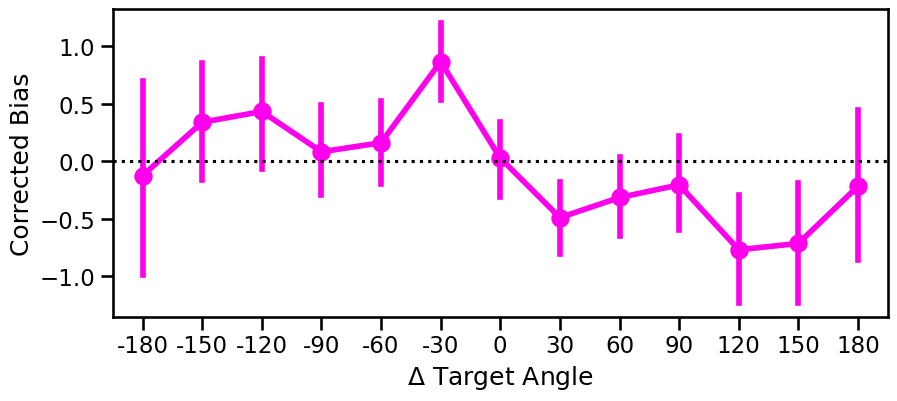

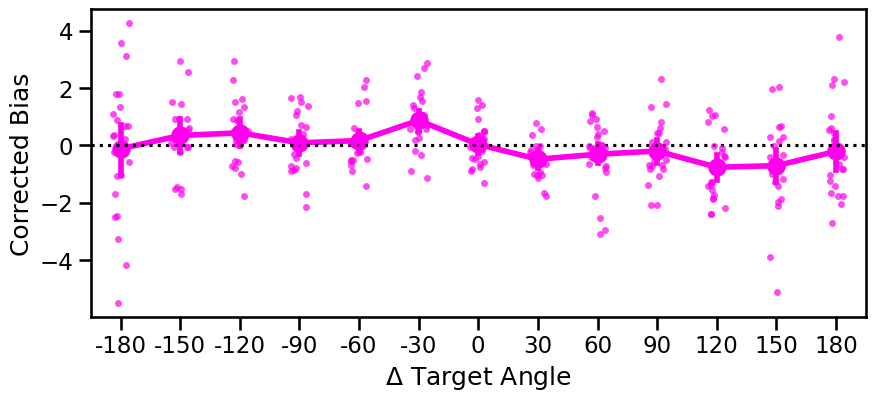

In [11]:
mask = ((SST2['TrialNumber'] >= epochs['repulse'][0]) & (SST2['TrialNumber'] <= epochs['repulse'][1]) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))
df_repulse = SST2.loc[mask, ['Prolific_ID', 'Bias', 'TargetAngle', 'TargetAngleN1Diff', 'AngleError', 'AngleError_Corrected']]

subject_means = (
    df_repulse
    .groupby(['Prolific_ID', 'TargetAngleN1Diff'])['AngleError_Corrected']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    #color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

# Plot bias for N, where N-1 is constrained to each target location (to visualize variability of repulsive effect between targets)

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_59314/2138254308.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_repulse60 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=60)
/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_59314/2138254308.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_repulse90 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=90)
/v

Text(0, 0.5, 'Corrected Bias')

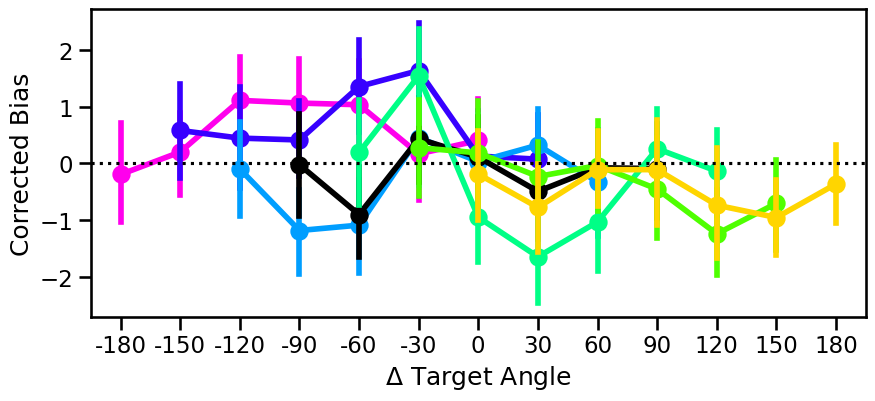

In [12]:
mask = ((SST2['TrialNumber'] >= epochs['repulse'][0]) & (SST2['TrialNumber'] <= epochs['repulse'][1]) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))
df_repulse = SST2.loc[mask].reset_index(drop=True)

df_repulse60 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=60)
df_repulse90 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=90)
df_repulse120 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=120)
df_repulse150 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=150)
df_repulse180 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=180)
df_repulse210 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=210)
df_repulse240 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=240)

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse60,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    #label=r'Trial N-1 = $60^\circ$'
)
sns.pointplot(
    data=df_repulse90,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    #label=r'Trial N-1 = $90^\circ$'
)
sns.pointplot(
    data=df_repulse120,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    #label=r'Trial N-1 = $120^\circ$'
)
sns.pointplot(
    data=df_repulse150,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    color='black',
    ax=ax,
    #label=r'Trial N-1 = $150^\circ$'
)
sns.pointplot(
    data=df_repulse180,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    #label=r'Trial N-1 = $180^\circ$'
)
sns.pointplot(
    data=df_repulse210,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    #label=r'Trial N-1 = $210^\circ$'
)
sns.pointplot(
    data=df_repulse240,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    #label=r'Trial N-1 = $240^\circ$'
)
ax.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')
#plt.legend(fontsize='small')

# Plot bias for N where N-1 is 150 (for comparison to UDL phase)

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_59314/1524544953.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_repulse150 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=150)


Text(0, 0.5, 'Corrected Bias')

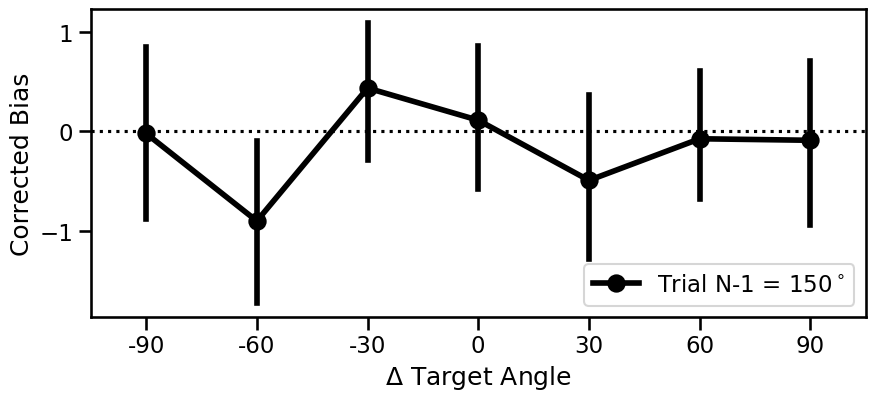

In [13]:
mask = ((SST2['TrialNumber'] >= epochs['repulse'][0]) & (SST2['TrialNumber'] <= epochs['repulse'][1]) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))
df_repulse = SST2.loc[mask].reset_index(drop=True)

df_repulse150 = df_repulse.groupby('Prolific_ID').apply(N_finder,N_minus_targ=150)
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse150,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    color='black',
    ax=ax,
    label=r'Trial N-1 = $150^\circ$'
)

ax.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')
#plt.legend()

# Plotting biases in use-dependent phase

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_59314/2899260827.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_udl_constrained = df_udl.groupby('Prolific_ID', as_index=False).apply(N_finder, N_minus_targ=150)


Text(0, 0.5, 'Corrected Bias')

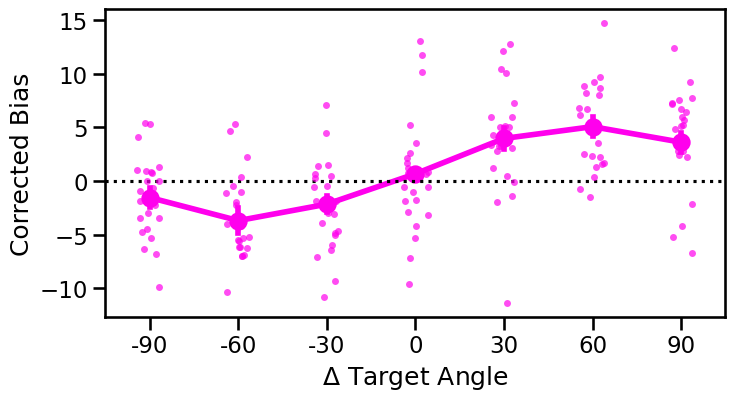

In [14]:
mask = ((SST2['TrialNumber'] >= epochs['udl'][0]) & (SST2['TrialNumber'] <= epochs['udl'][1]) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))

df_udl = SST2.loc[mask]
df_udl_constrained = df_udl.groupby('Prolific_ID', as_index=False).apply(N_finder, N_minus_targ=150)

subject_means = df_udl_constrained.groupby(['Prolific_ID', 'TargetAngleN1Diff'])['AngleError_Corrected'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8,4))
sns.pointplot(
    data=df_udl_constrained,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
sns.stripplot(
    data=subject_means,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

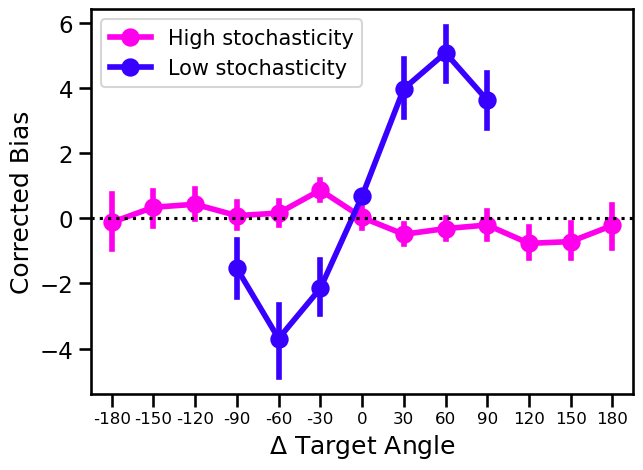

In [15]:
fig, ax = plt.subplots(figsize=(7,5))
sns.pointplot(
    data=df_repulse,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax,
    label='High stochasticity'
)

sns.pointplot(
    data=df_udl_constrained,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='red',
    ax=ax,
    label='Low stochasticity'
)

ax.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')
plt.legend(fontsize='small')
ax.tick_params(axis='x', labelsize=12)

# Plot biases for trial N reaches *to* repeated target, seperated by different targets for N-1 

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_59314/2997628850.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_udl_returns = df_udl.groupby('Prolific_ID').apply(N_finder_alt)


Text(0, 0.5, 'Corrected Bias')

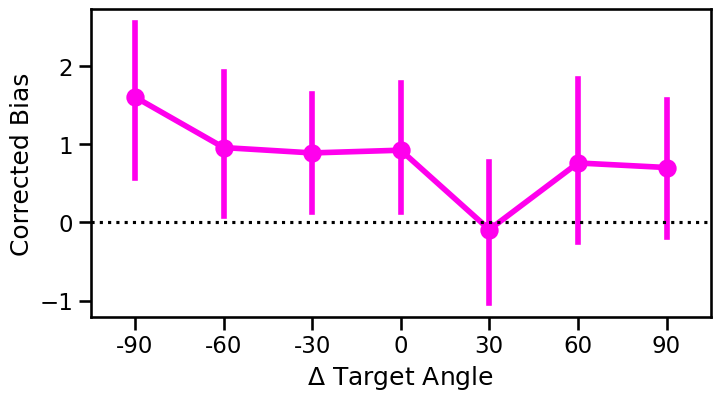

In [16]:
mask = ((SST2['TrialNumber'] >= epochs['udl'][0]) & (SST2['TrialNumber'] <= epochs['udl'][1] - 1) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))

df_udl = SST2.loc[mask]

def N_finder_alt(group):
    N_trial_num = group.loc[(group['Probe'] == 1),'TrialNumber'] + 1
    N_df = group.loc[(group['TrialNumber'].isin(N_trial_num)) & (group['TargetAngle'] == 150)]
    return N_df

df_udl_returns = df_udl.groupby('Prolific_ID').apply(N_finder_alt)

subject_means = (df_udl.groupby(['Prolific_ID', 'TargetAngleN1Diff'])['AngleError_Corrected'].mean().reset_index())

fig, ax = plt.subplots(figsize=(8,4))
sns.pointplot(
    data=df_udl_returns,
    x='TargetAngleN1Diff',
    y='AngleError_Corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

# Plot SE difference (summed error), which is positive for a repulsive effect and negative for an attractive effect

(-10.0, 3.0)

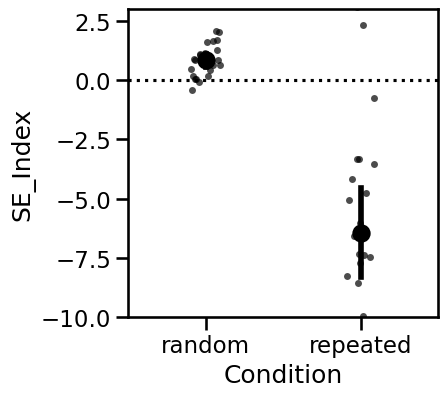

In [ ]:
Good_Trials_repulse = ((SST2['TrialNumber'] >= epochs['repulse'][0]) & (SST2['TrialNumber'] <= epochs['repulse'][1]) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))

Good_Trials_udl = ((SST2['TrialNumber'] >= epochs['udl'][0]) & (SST2['TrialNumber'] <= epochs['udl'][1])  & (SST2['Probe'] == 1) & (SST2['MT'] < 500) & (SST2['RT'] > 500) & (SST2['AngleError'].abs() < 60))

se_index_1 = SST2.loc[Good_Trials_repulse & (SST2['TargetAngleN1Diff']<0)].groupby('Prolific_ID')['AngleError_Corrected'].mean() - SST2.loc[Good_Trials_repulse & (SST2['TargetAngleN1Diff']>0)].groupby('Prolific_ID')['AngleError_Corrected'].mean()
se_index_2 = SST2.loc[Good_Trials_udl & (SST2['TargetAngleN1Diff']<0)].groupby('Prolific_ID')['AngleError_Corrected'].mean() - SST2.loc[Good_Trials_udl & (SST2['TargetAngleN1Diff']>0)].groupby('Prolific_ID')['AngleError_Corrected'].mean()

se_df = pd.DataFrame({'random': se_index_1,'repeated': se_index_2}).reset_index()

se_df = se_df.melt(id_vars='Prolific_ID',
                   var_name='Condition',
                   value_name='SE_Index')

fig, ax = plt.subplots(figsize=(4,4))

# sns.stripplot(
#    data=se_df,
#    x='Condition',
#    y='SE_Index',
#    color='black',
#    alpha=0.7,
#    jitter=True,
#    ax=ax
# )

sns.pointplot(
    data=se_df,
    x='Condition',
    y='SE_Index',
    estimator='mean',
    errorbar=('ci', 95),
    color='black',
    linestyles='',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
plt.ylim(-10,3)

In [18]:
# pdexp = pd.read_csv('pdexport.csv') # SetSize Table
# check_df = pdexp["Participant_id"].isin(SST2["Prolific_ID"].unique().flatten())
# display(pdexp["Participant_id"])
# display(check_df)

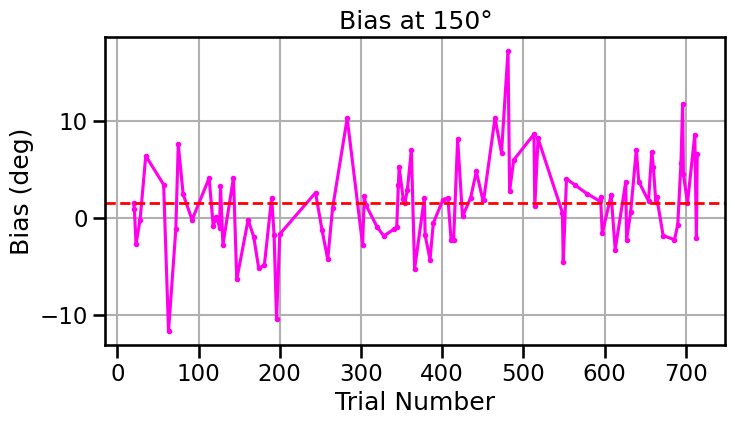

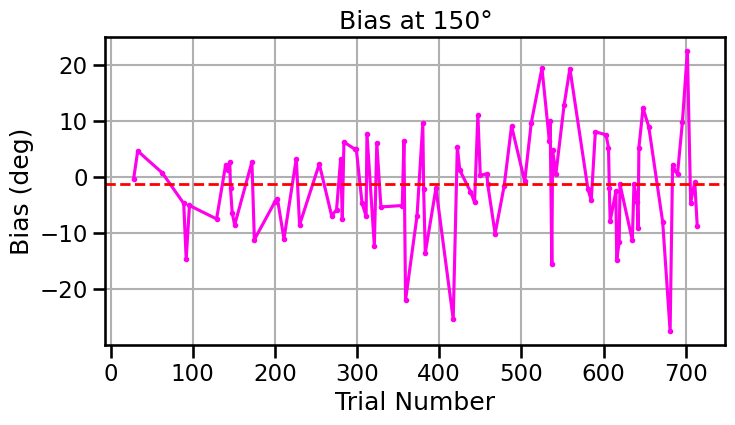

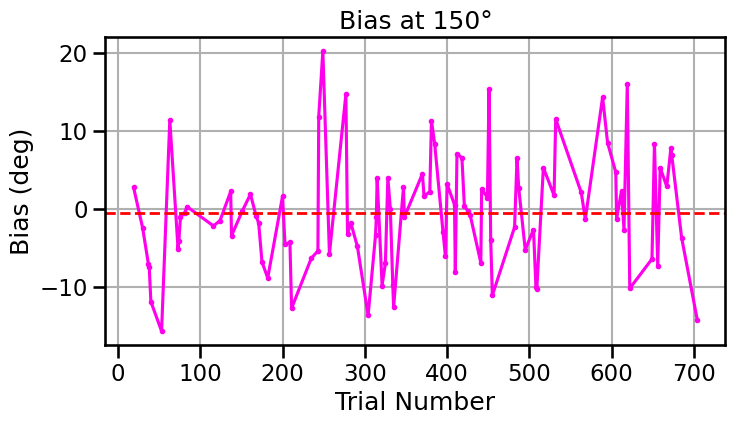

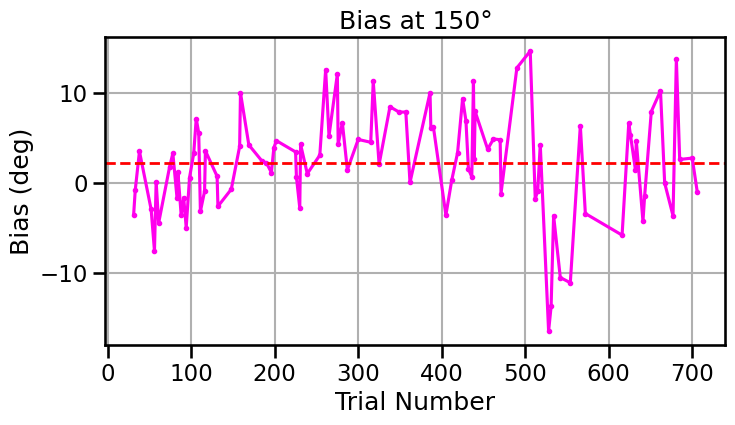

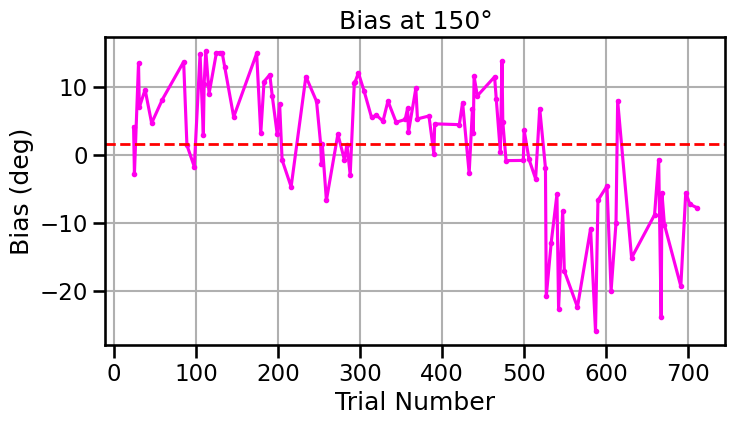

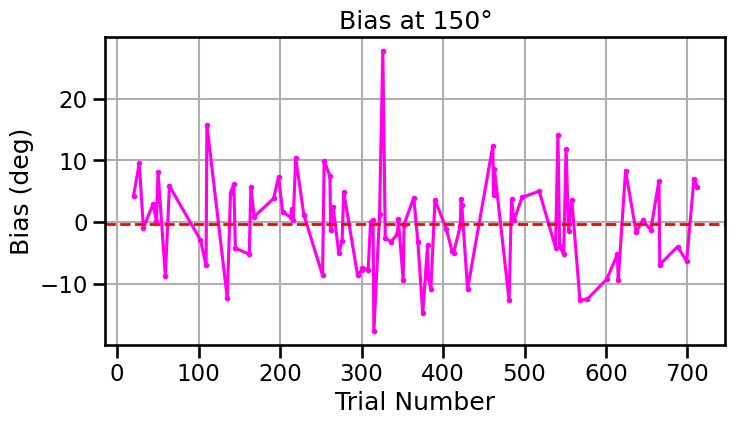

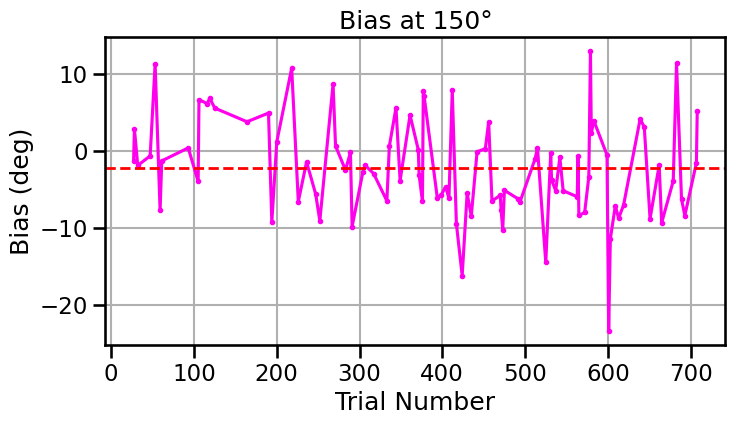

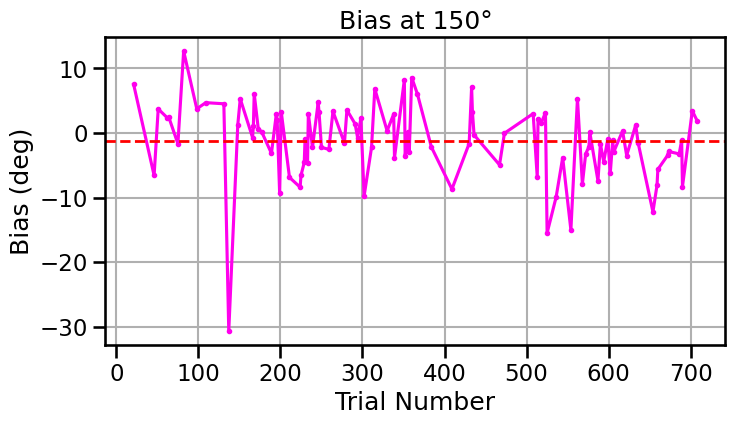

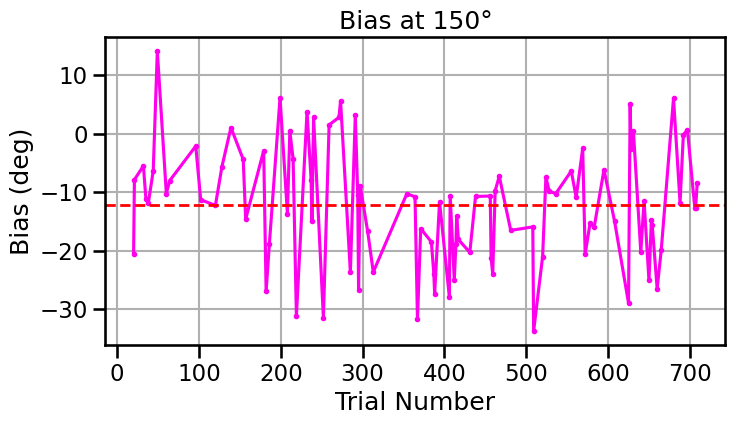

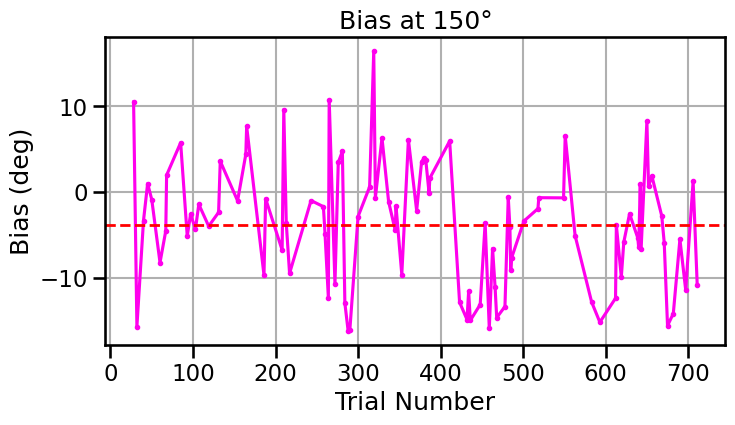

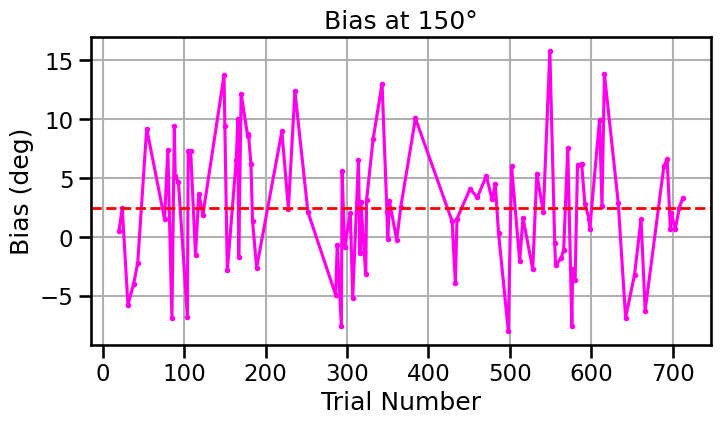

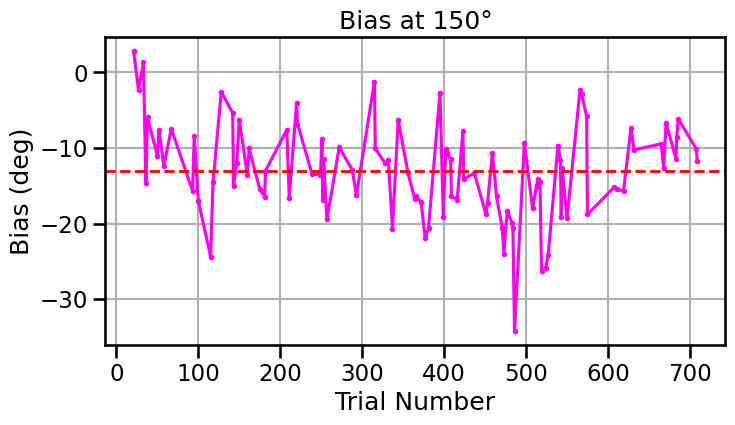

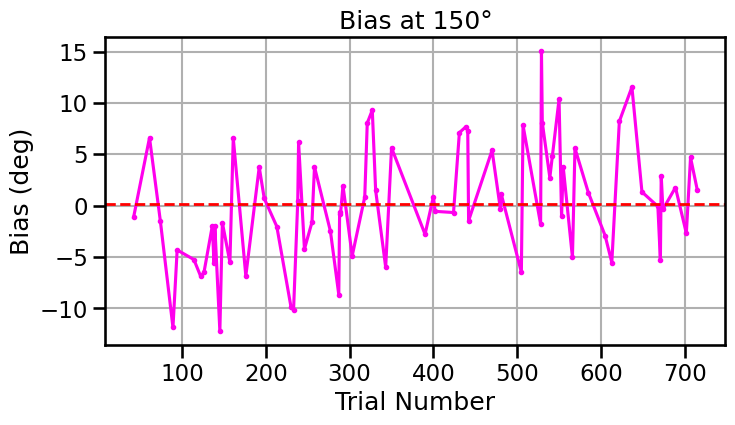

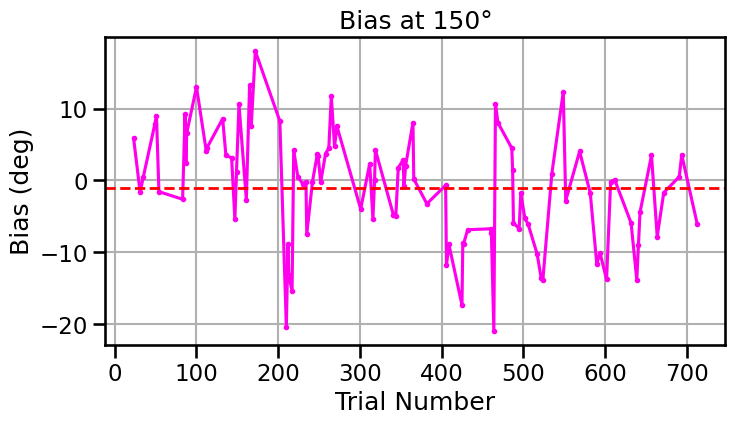

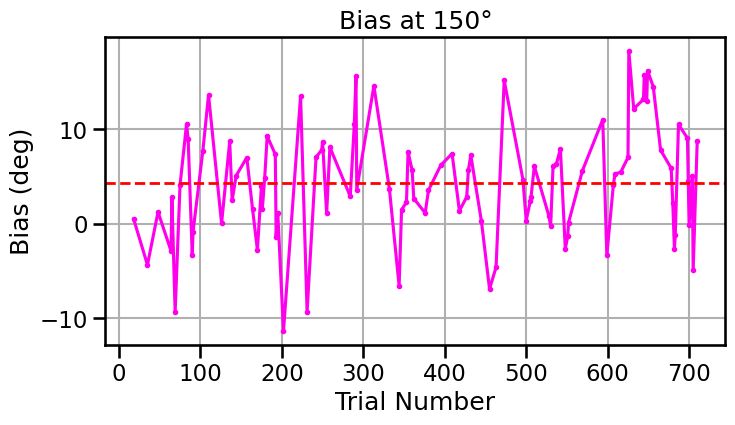

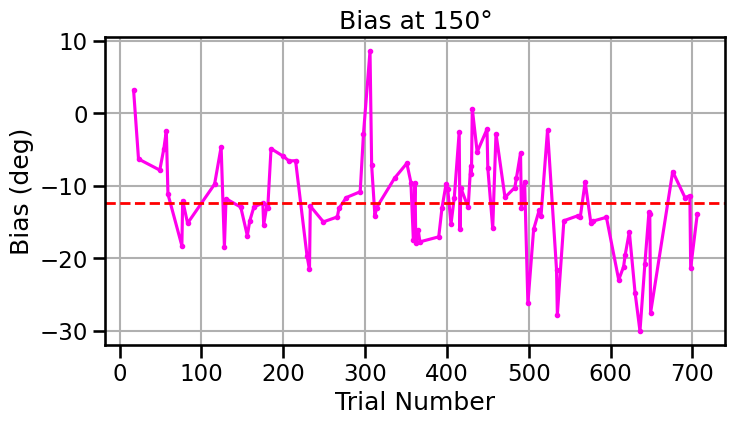

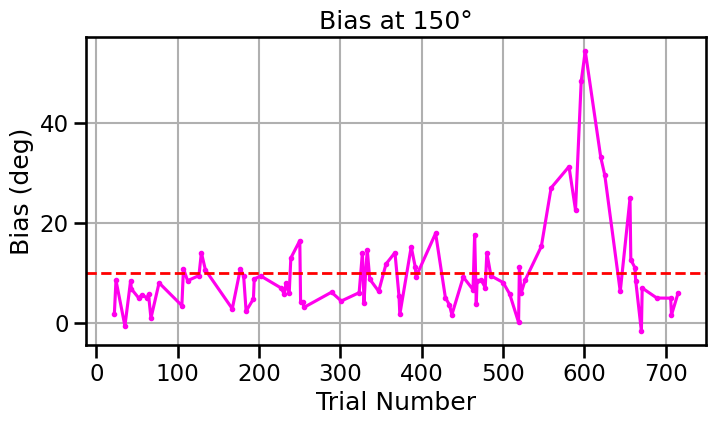

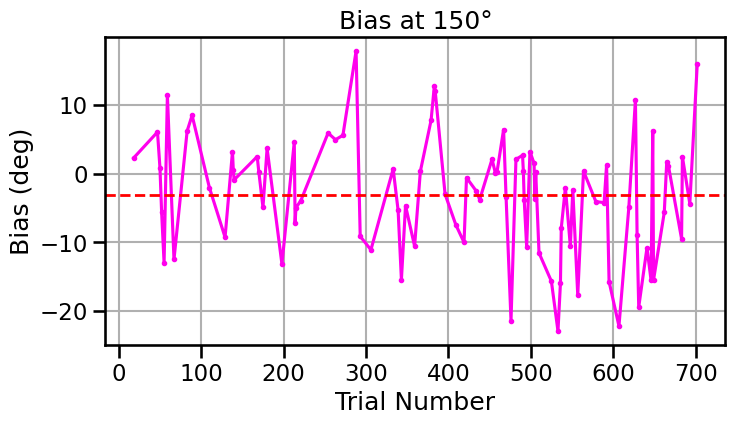

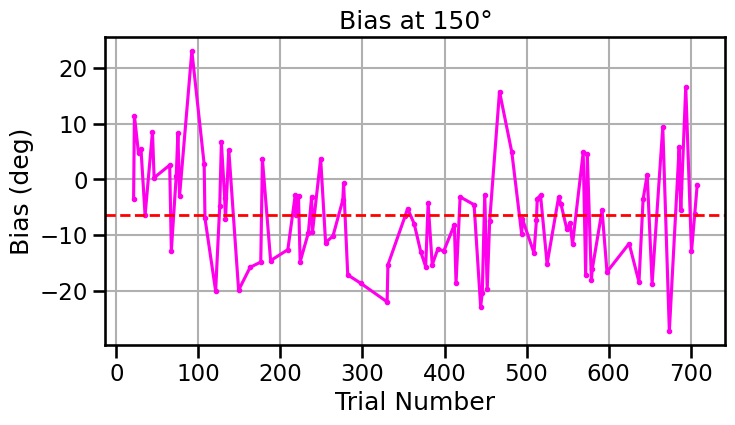

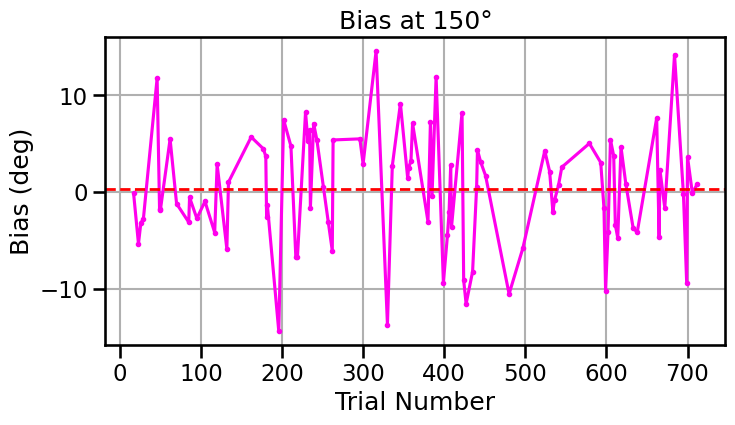

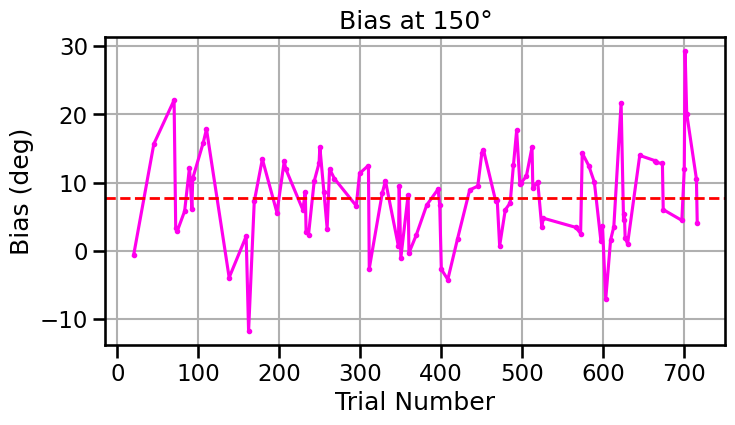

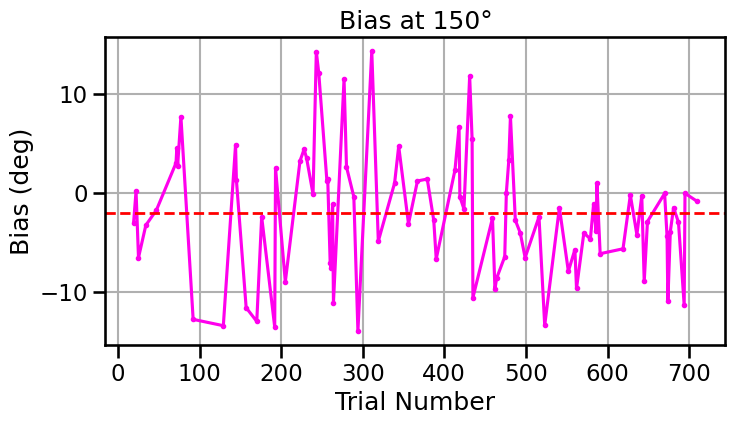

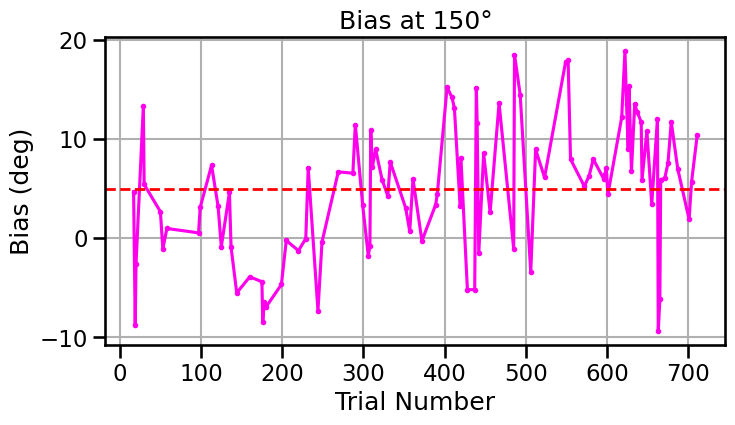

In [19]:
for id in df_repulse['Prolific_ID'].unique():
    df_sn = (
        df_repulse[
            (df_repulse["Prolific_ID"] == id) &
            ## CHANGE HERE FOR ANGLE 
            (df_repulse["TargetAngle"] == 150 )
        ] # look at all targets 
        .sort_values("TrialNumber")
    )

    plt.figure(figsize=(8, 4))
    plt.plot(df_sn["TrialNumber"], df_sn["AngleError"], 'o-', markersize=3)

    plt.xlabel("Trial Number")

    mean_val = df_repulse.loc[
        (df_repulse["Prolific_ID"] == id) &
        ## CHANGE HERE FOR ANGLE 
        (df_repulse["TargetAngle"] == 150),
        "AngleError"
    ].mean()

    plt.axhline(y=mean_val, color='r', linestyle='--', linewidth=2)
    plt.ylabel("Bias (deg)")
    ## CHANGE HERE FOR ANGLE 
    plt.title(f"Bias at 150°")
    plt.grid(True)
    plt.show()

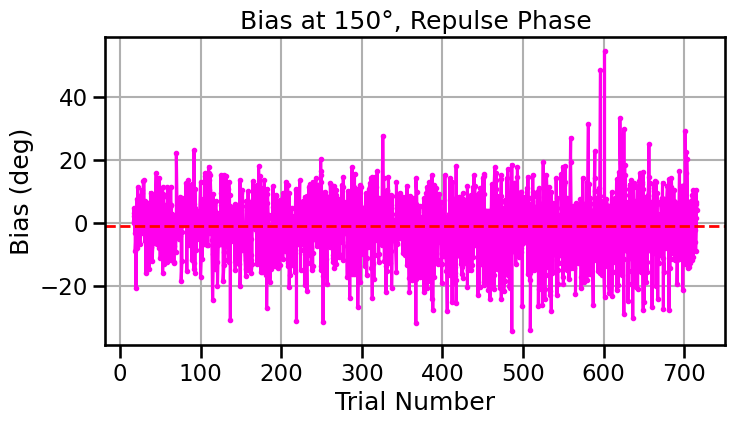

In [20]:
df_sn = (df_repulse[
        (df_repulse["TargetAngle"] == 150 )
        ].sort_values("TrialNumber")
    )

plt.figure(figsize=(8, 4))
plt.plot(df_sn["TrialNumber"], df_sn["AngleError"], 'o-', markersize=3)

plt.xlabel("Trial Number")

mean_val = df_repulse.loc[
## CHANGE HERE FOR ANGLE 
(df_repulse["TargetAngle"] == 150),"AngleError"].mean()

plt.axhline(y=mean_val, color='r', linestyle='--', linewidth=2)
plt.ylabel("Bias (deg)")
## CHANGE HERE FOR ANGLE 
plt.title(f"Bias at 150°, Repulse Phase")
plt.grid(True)
plt.show()

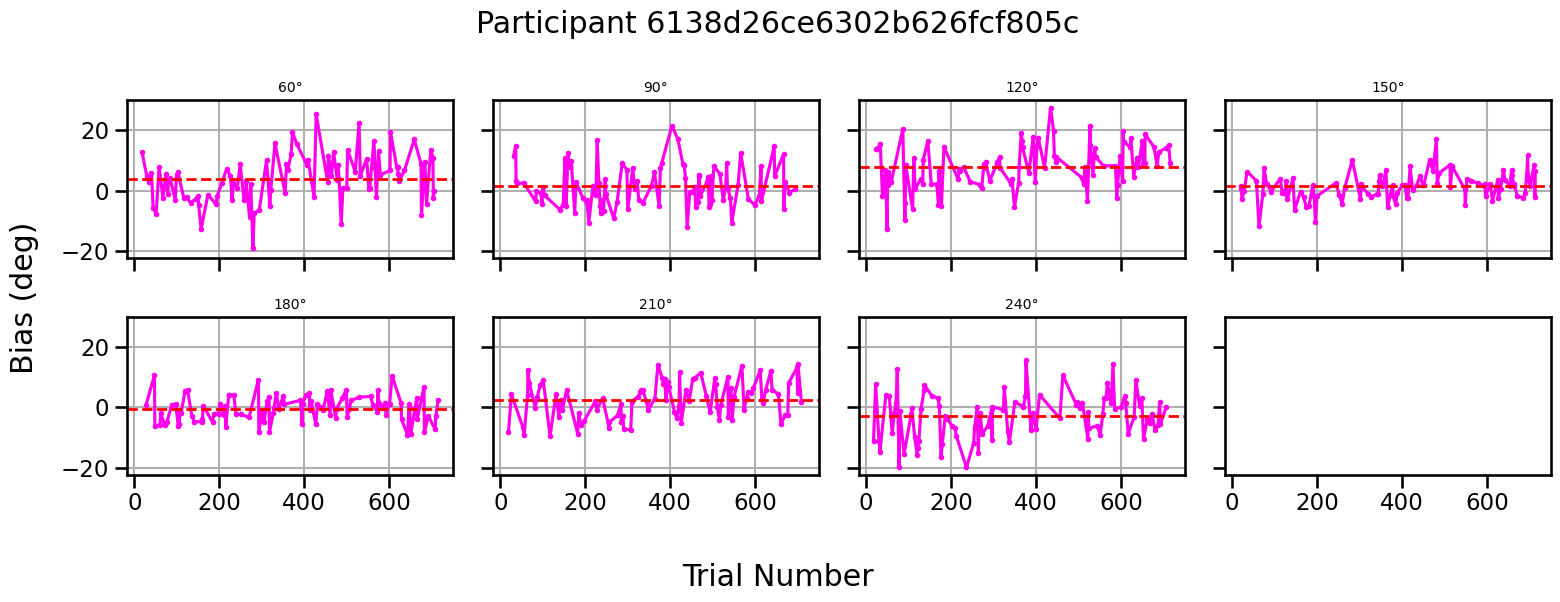

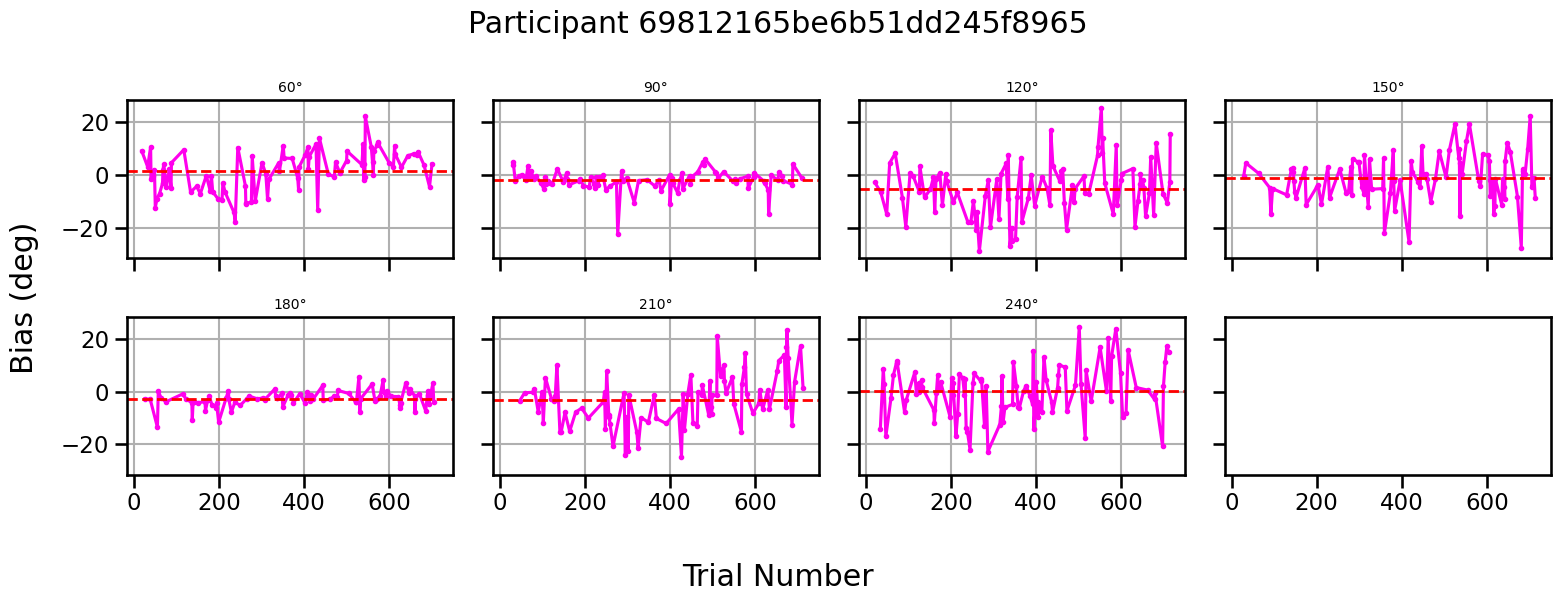

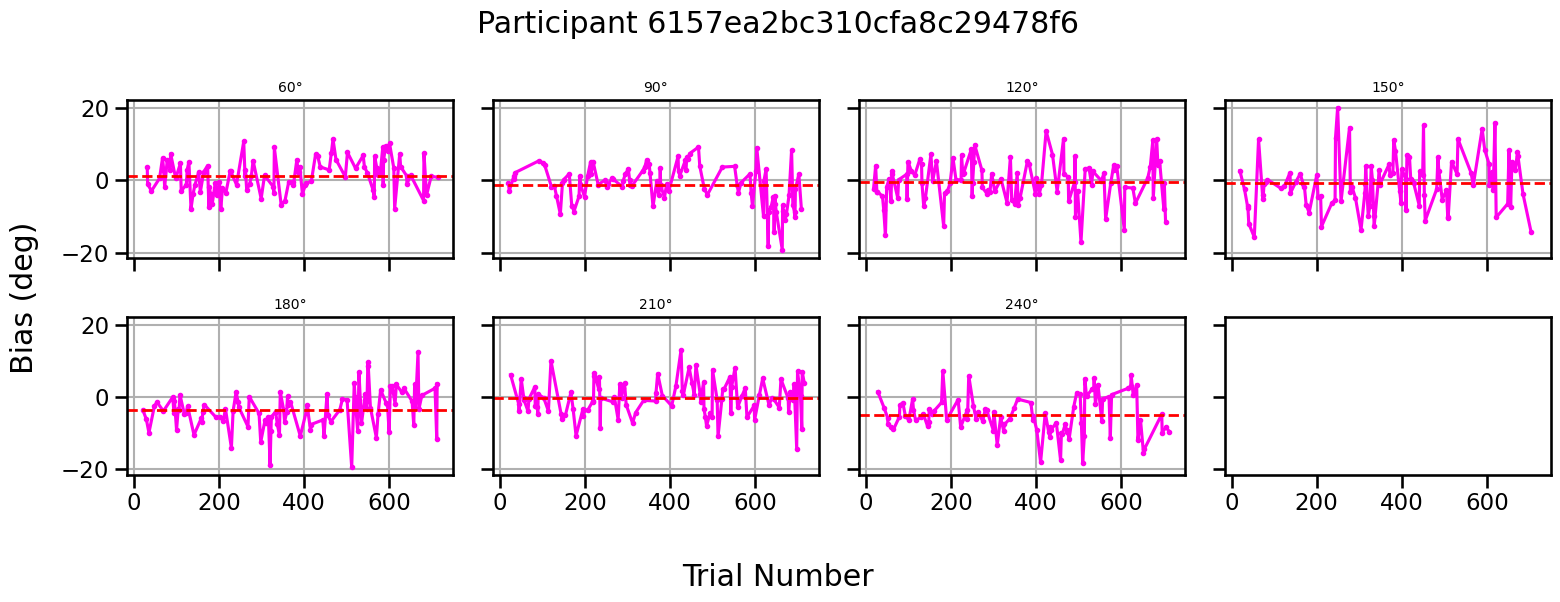

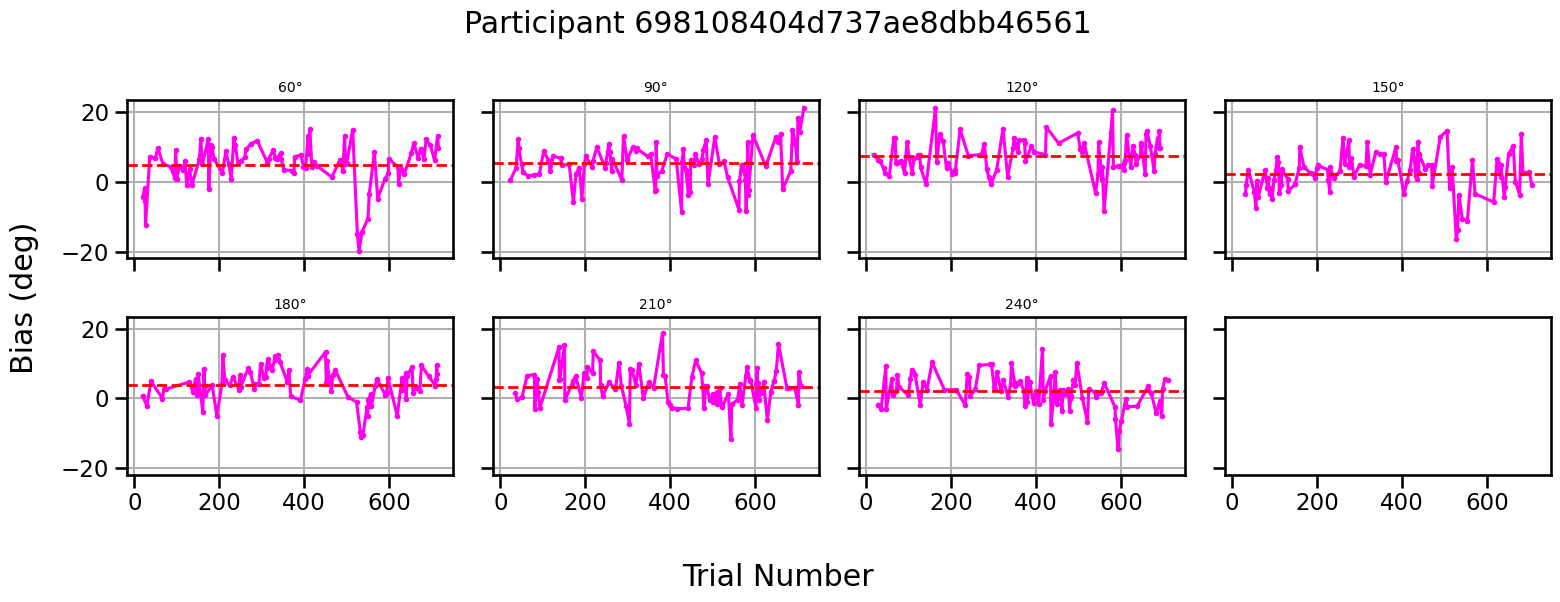

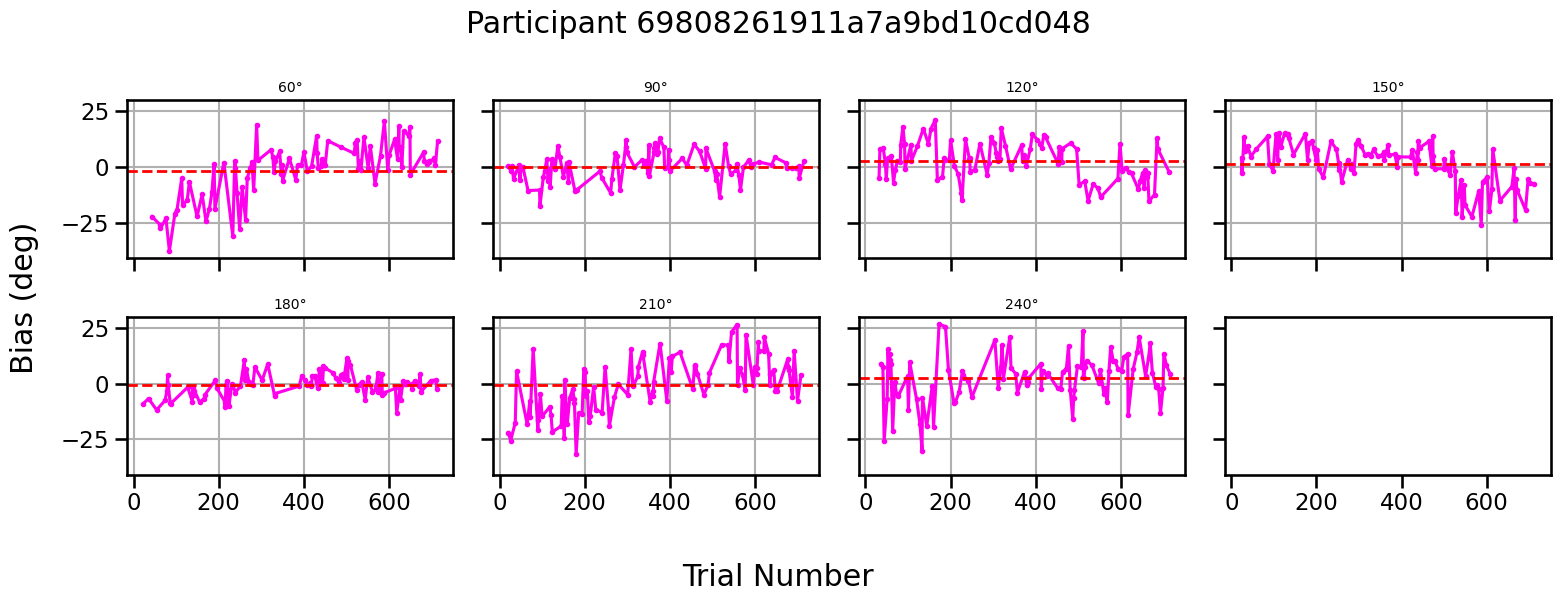

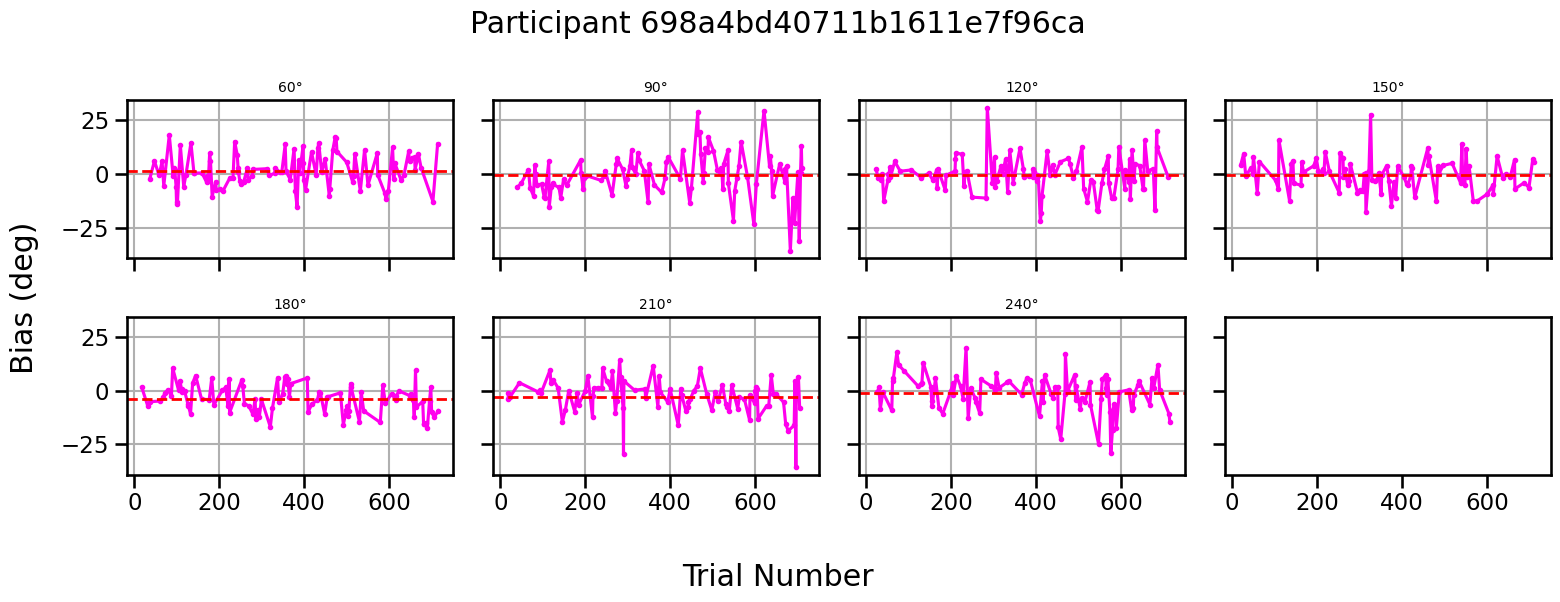

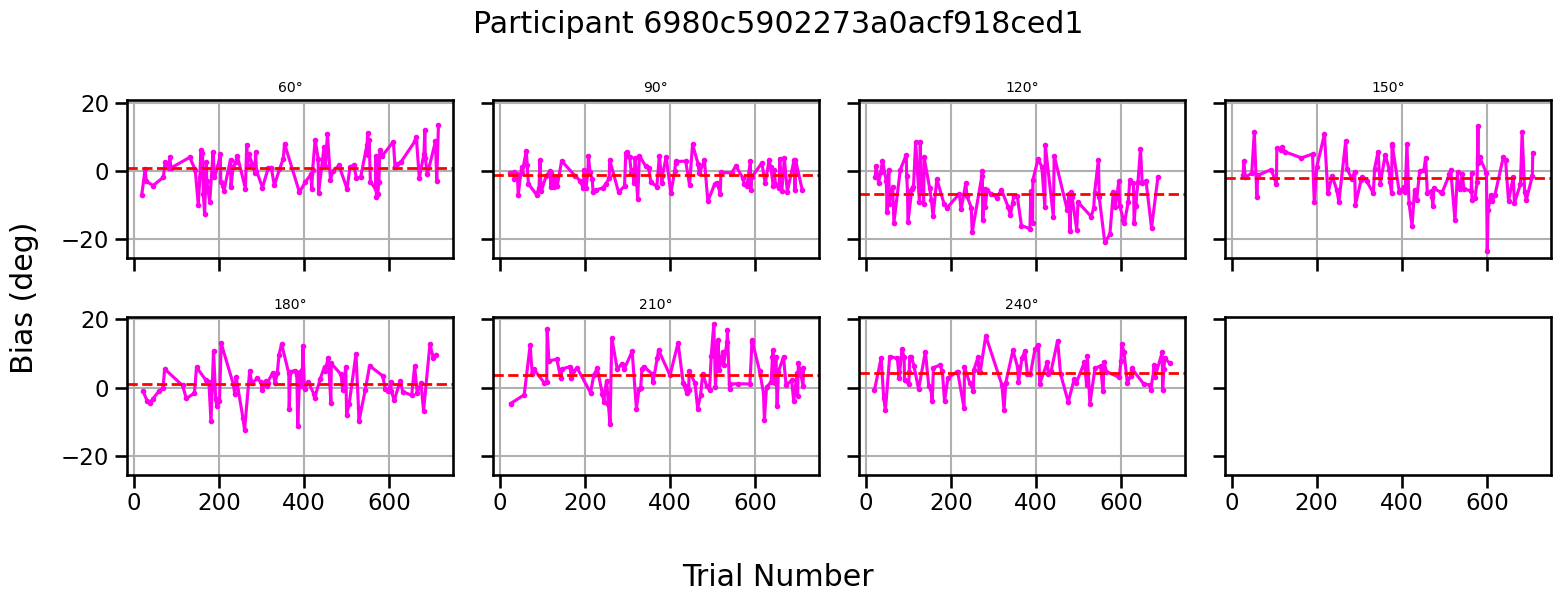

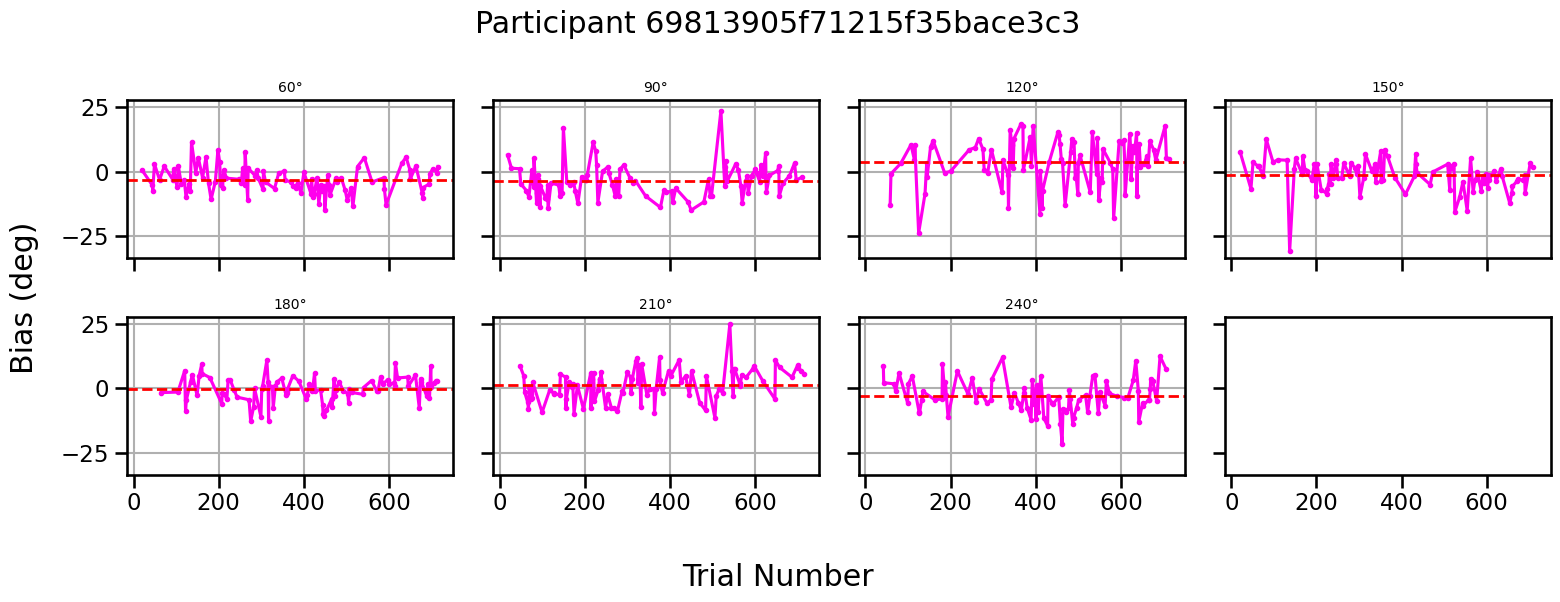

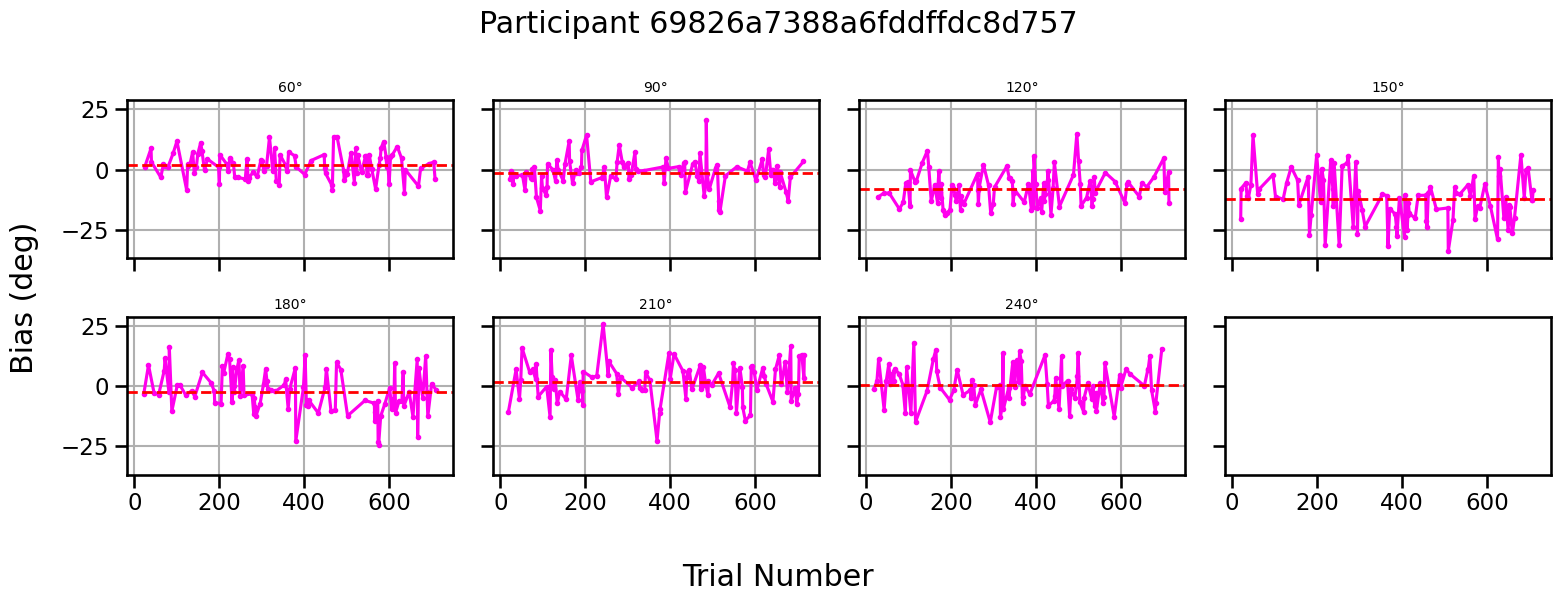

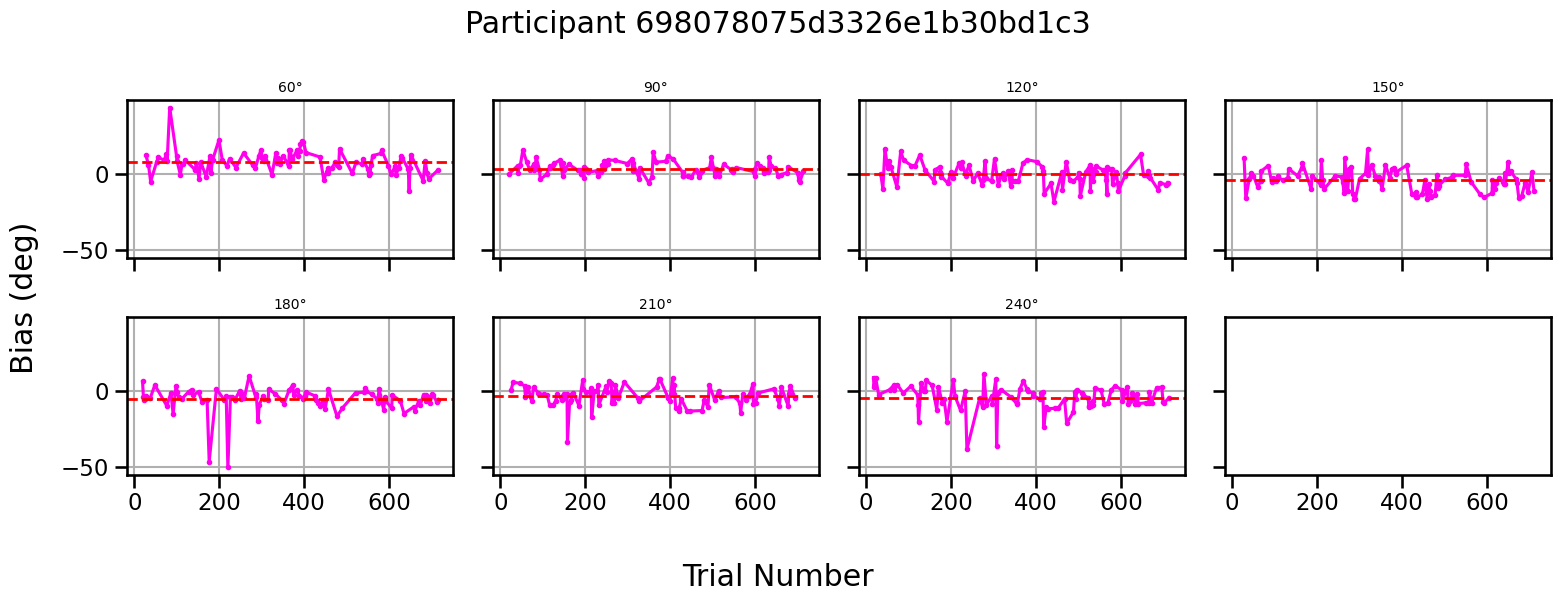

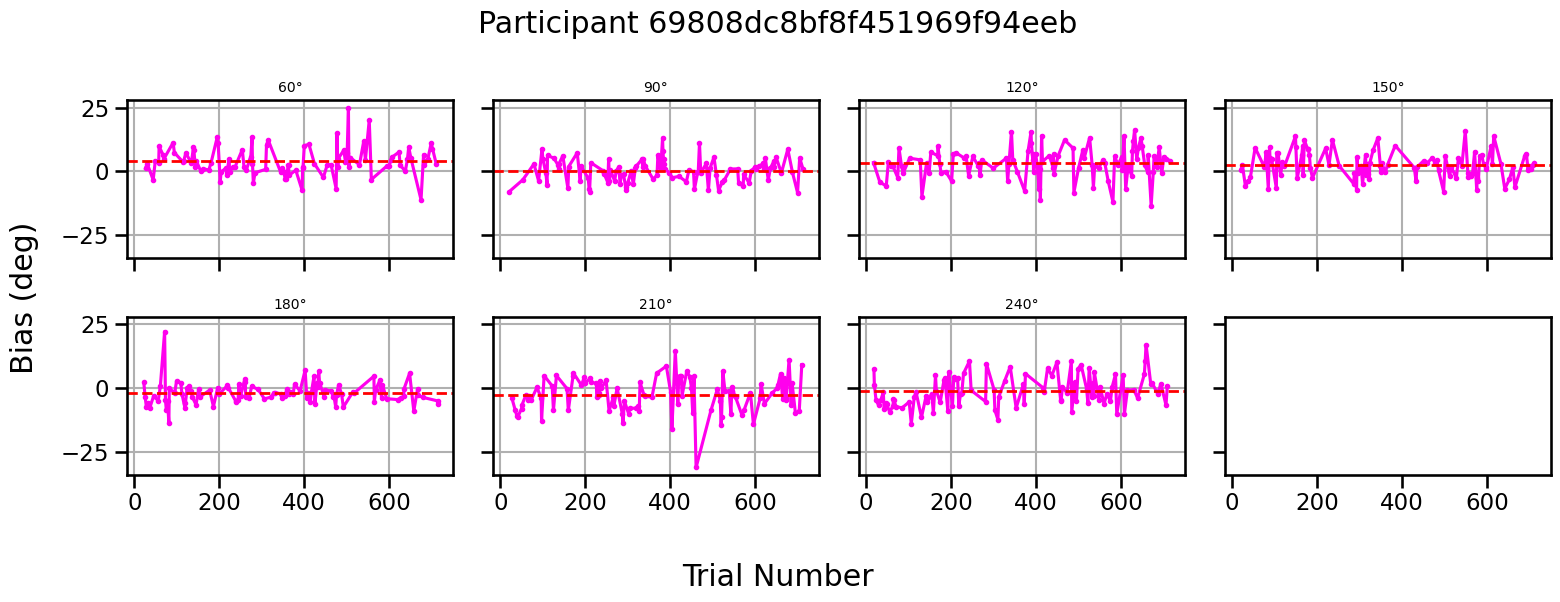

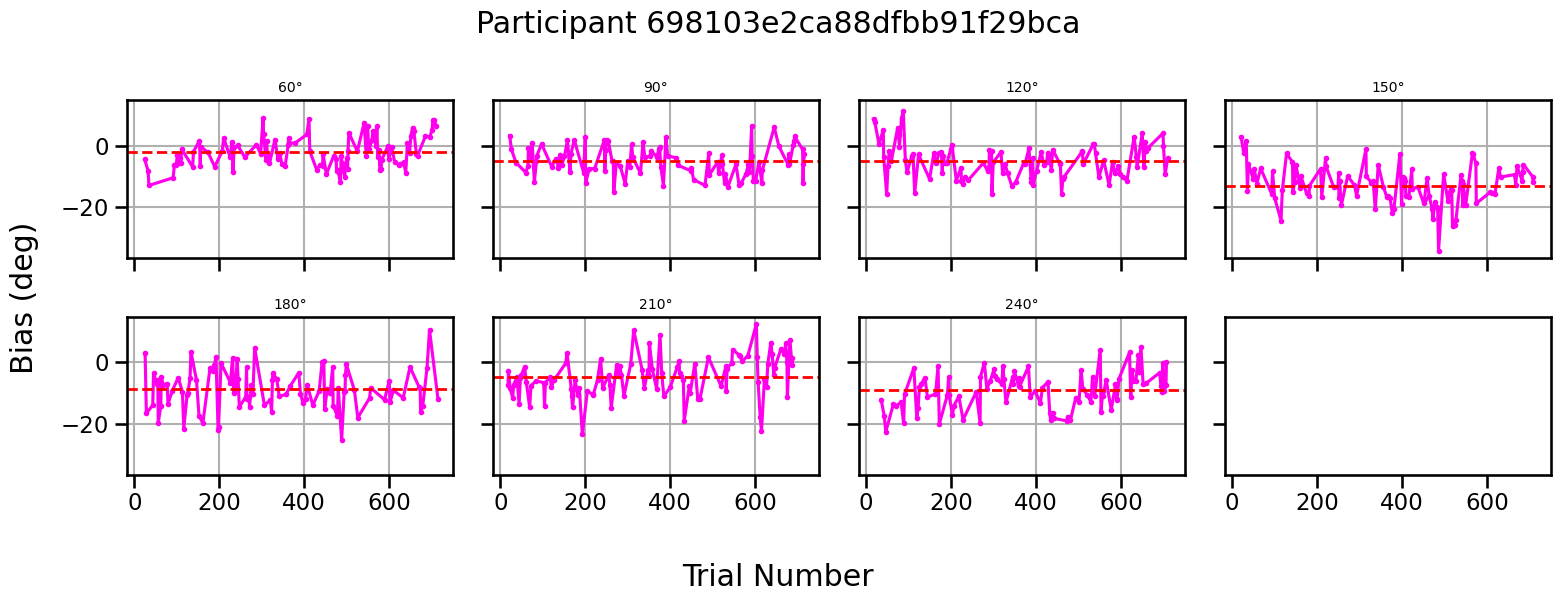

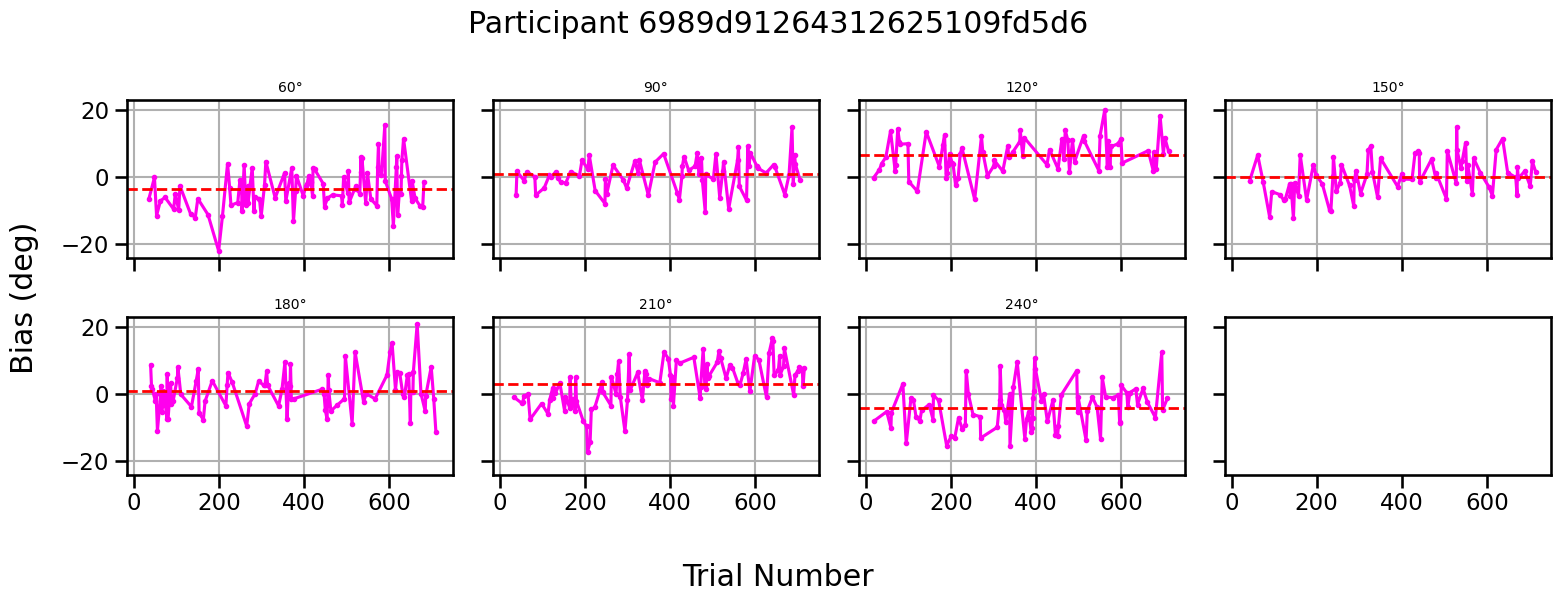

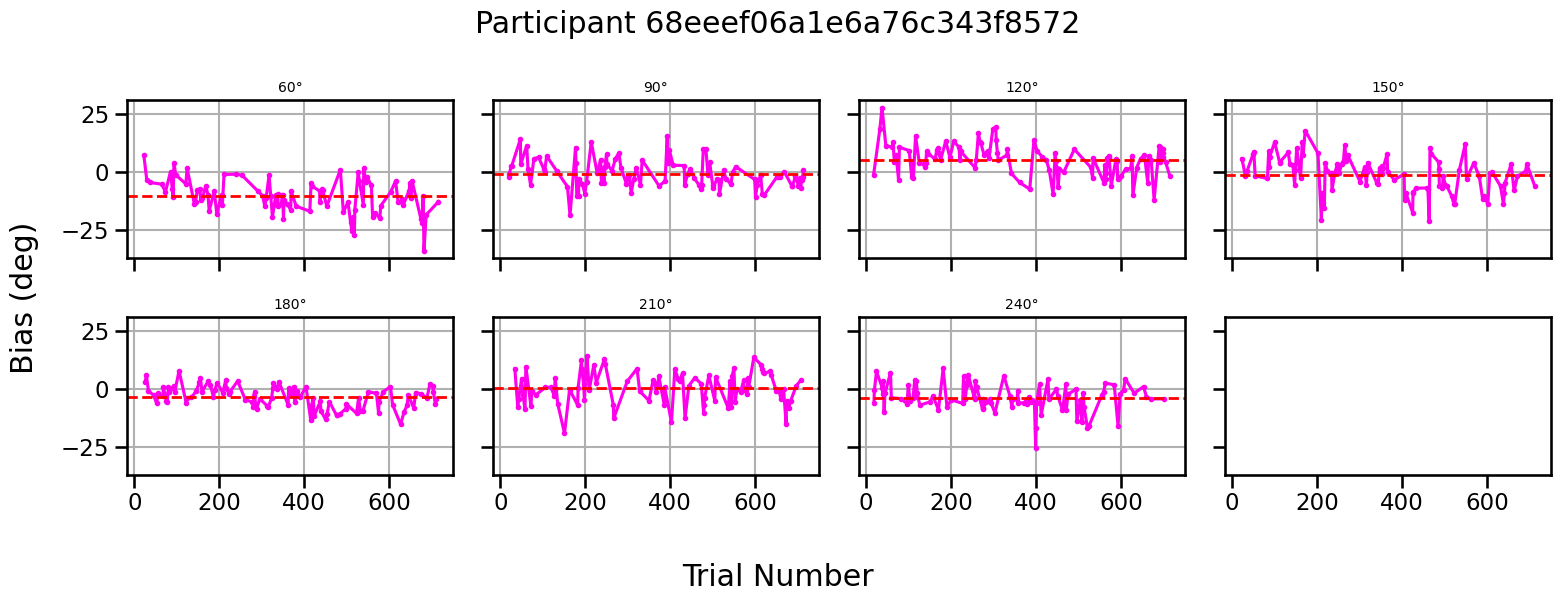

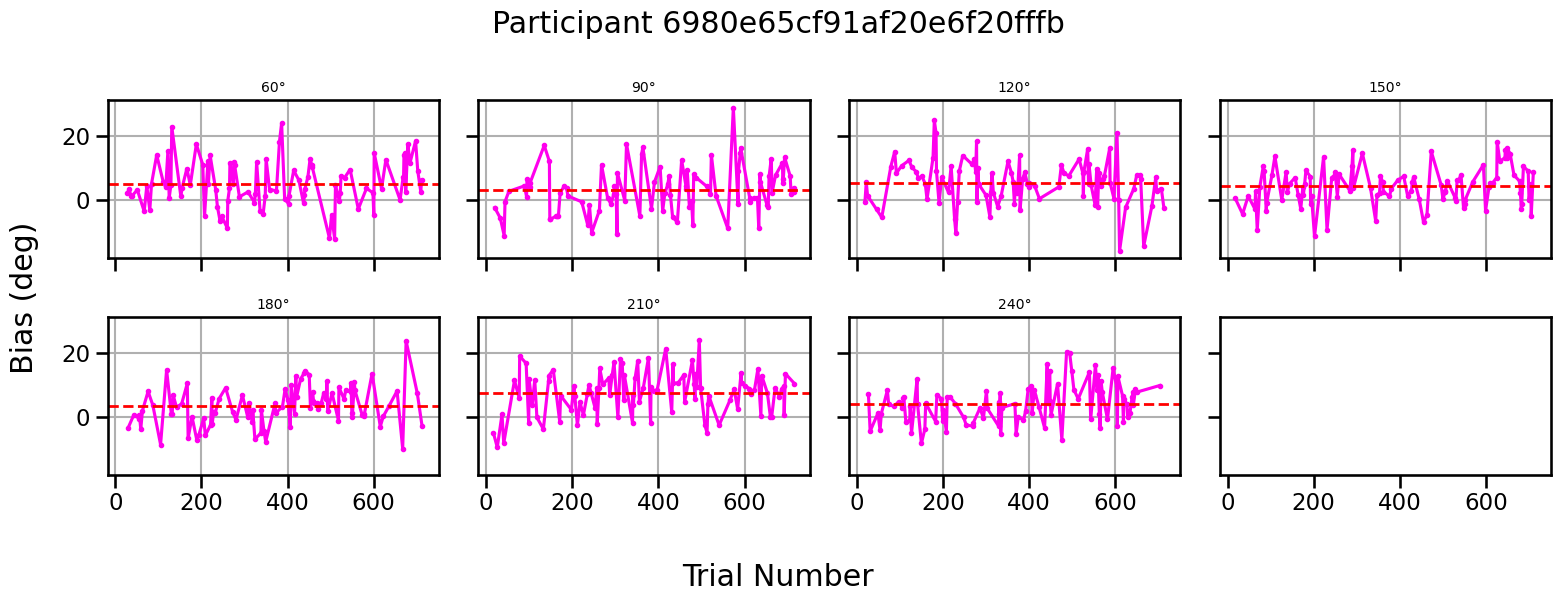

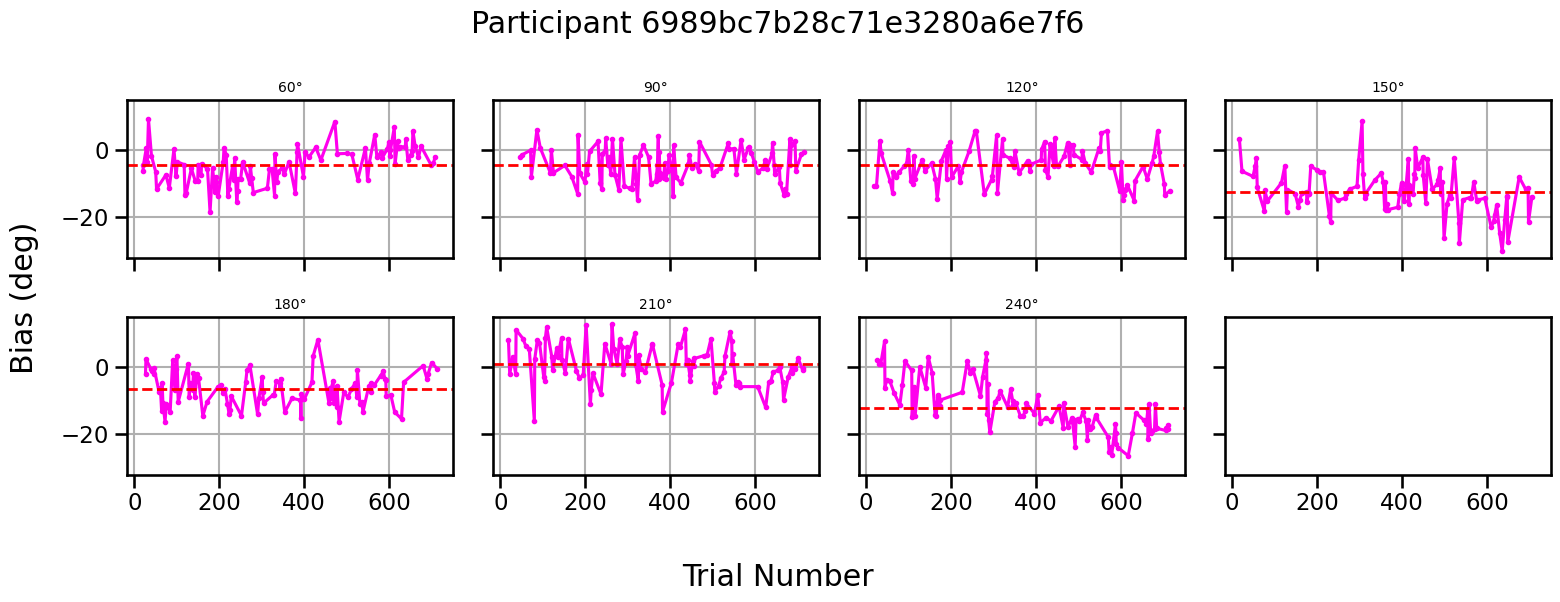

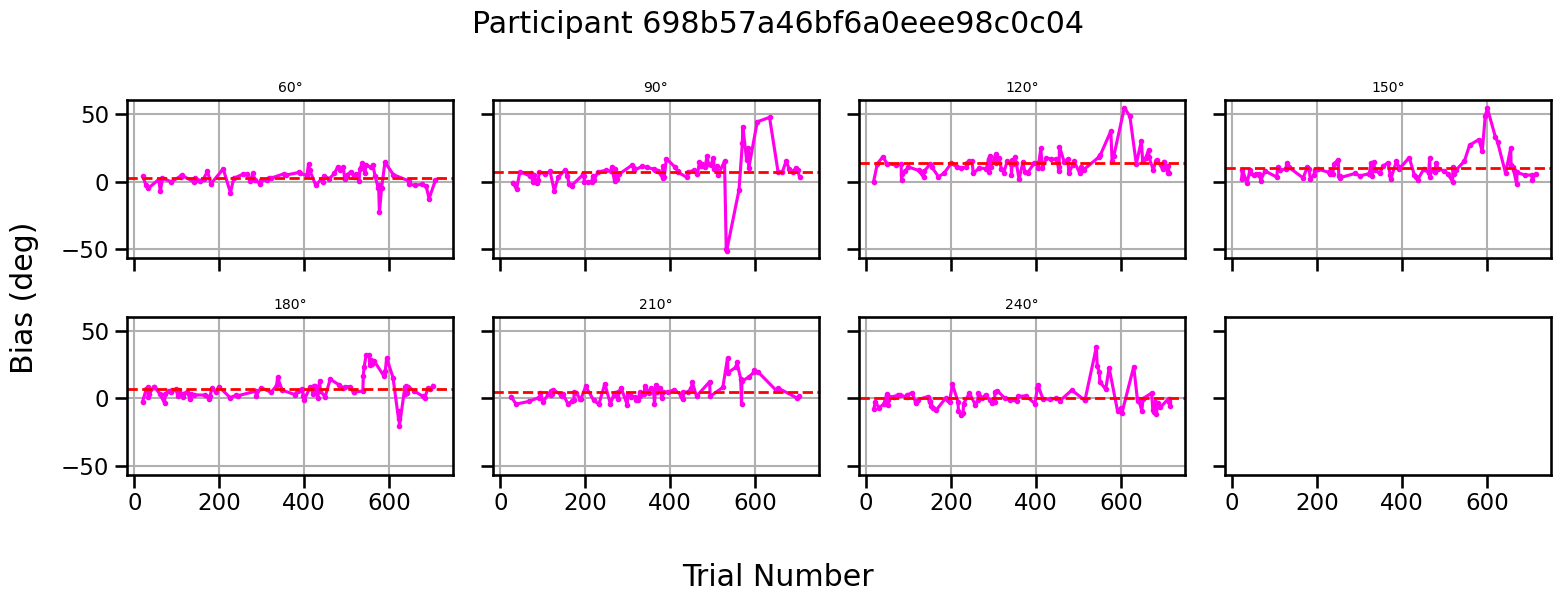

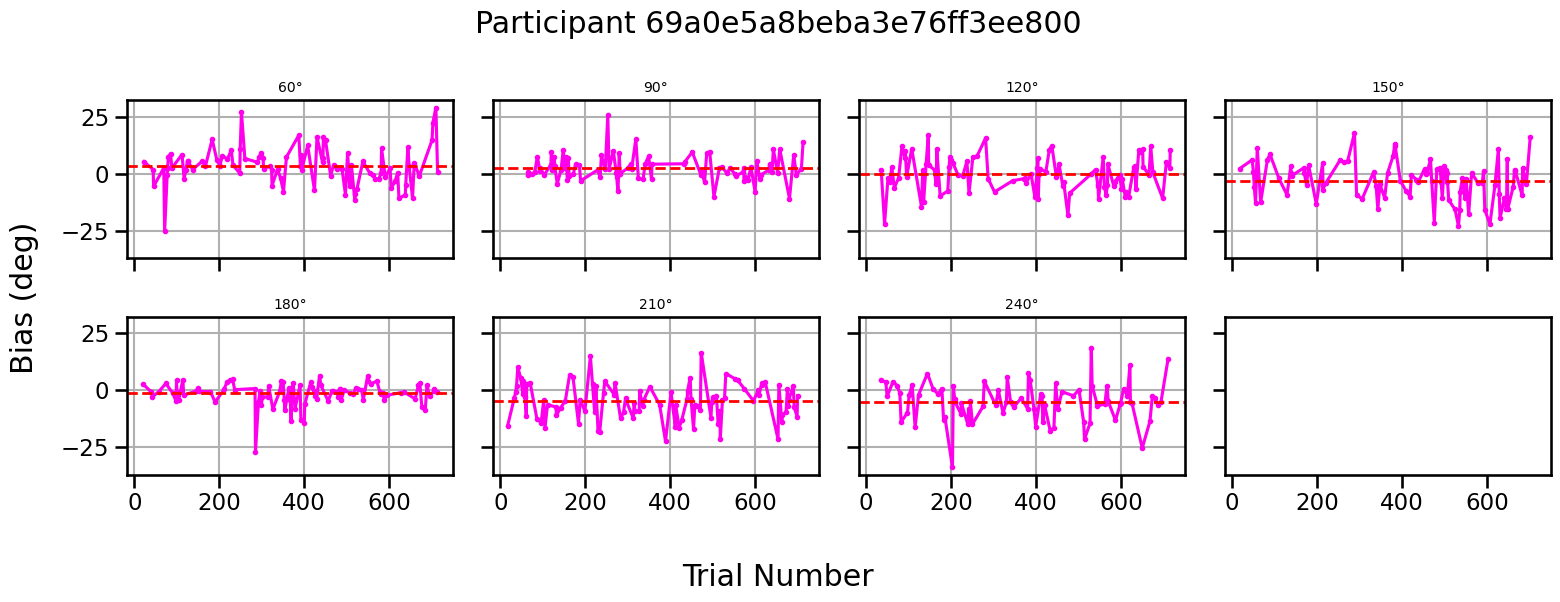

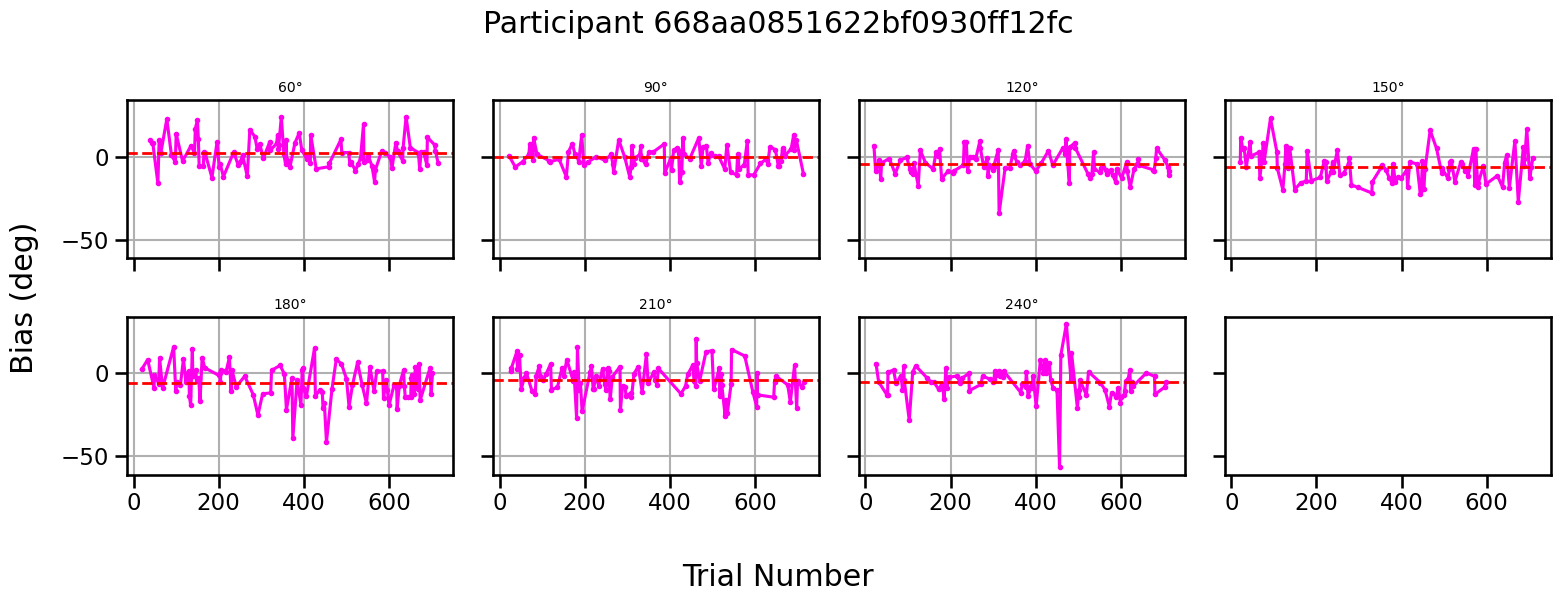

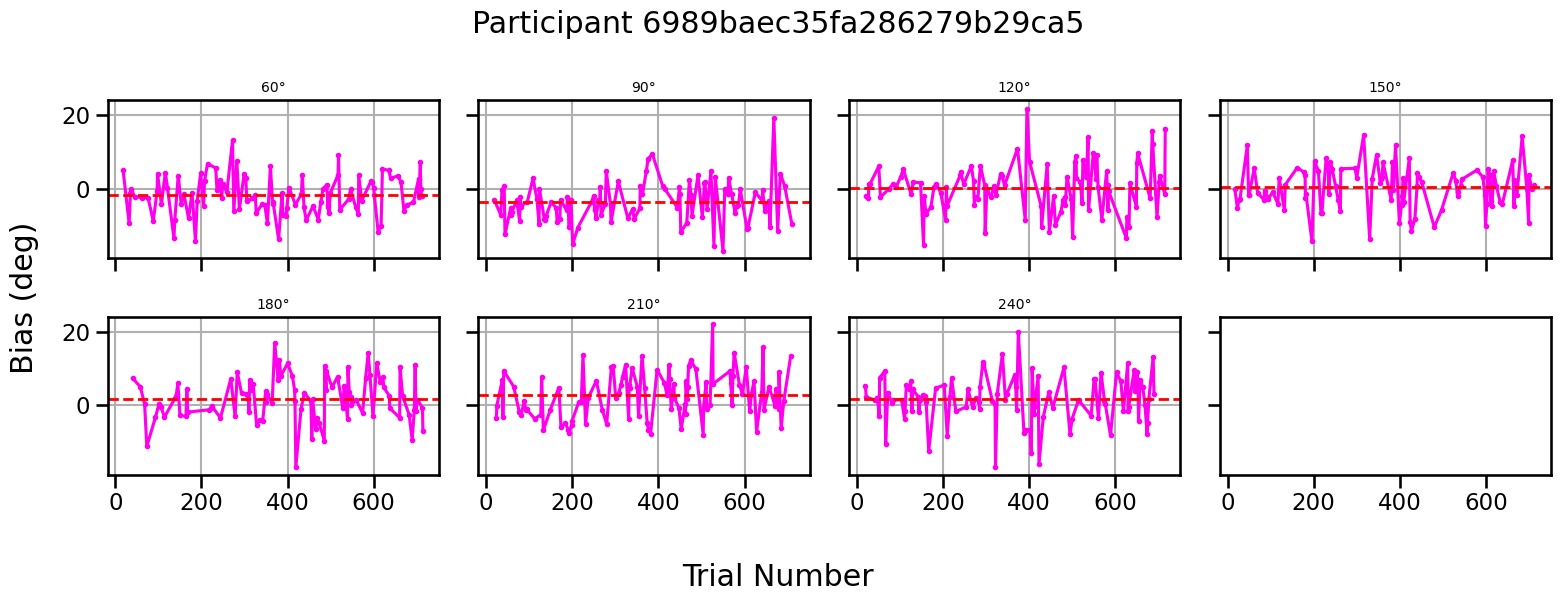

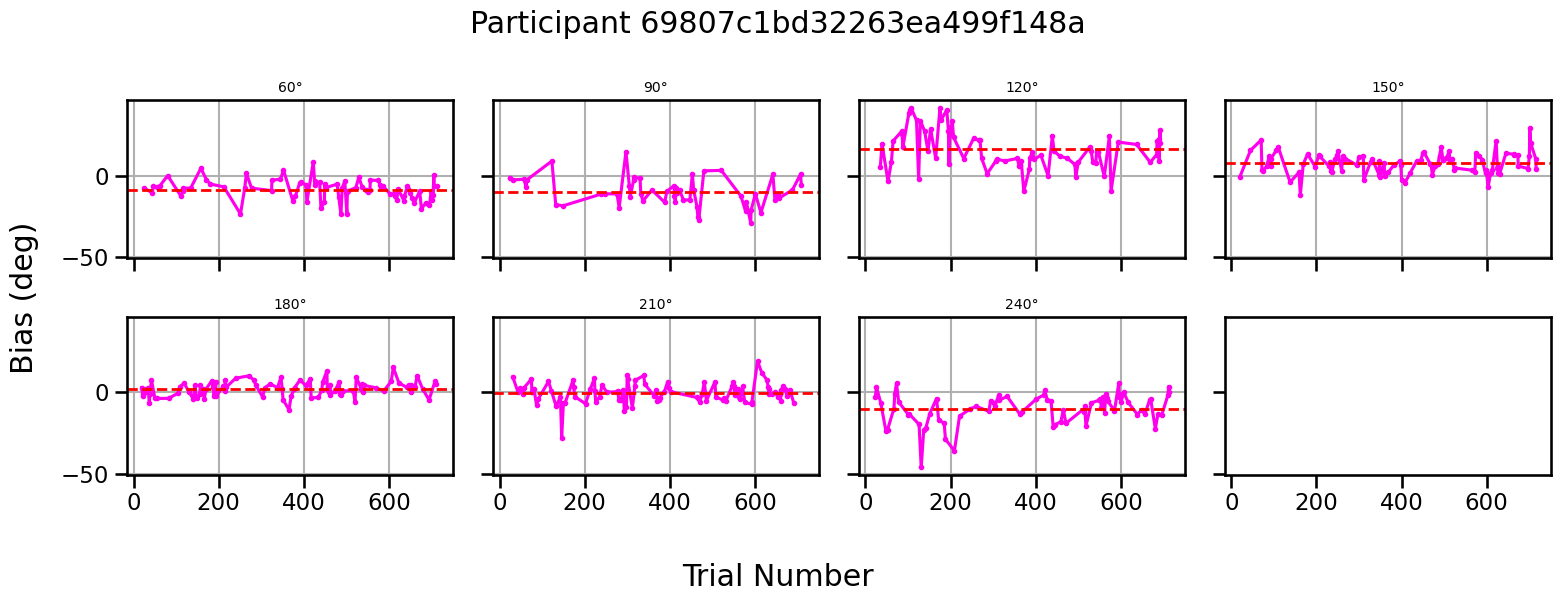

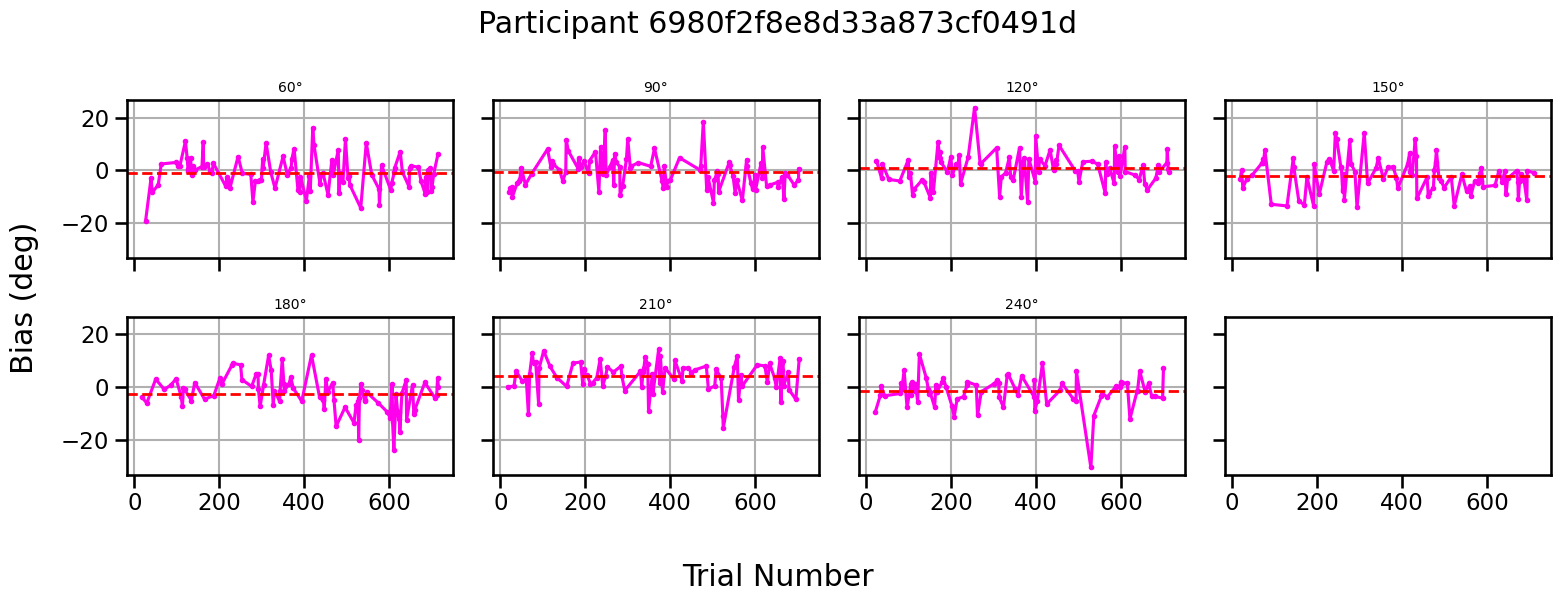

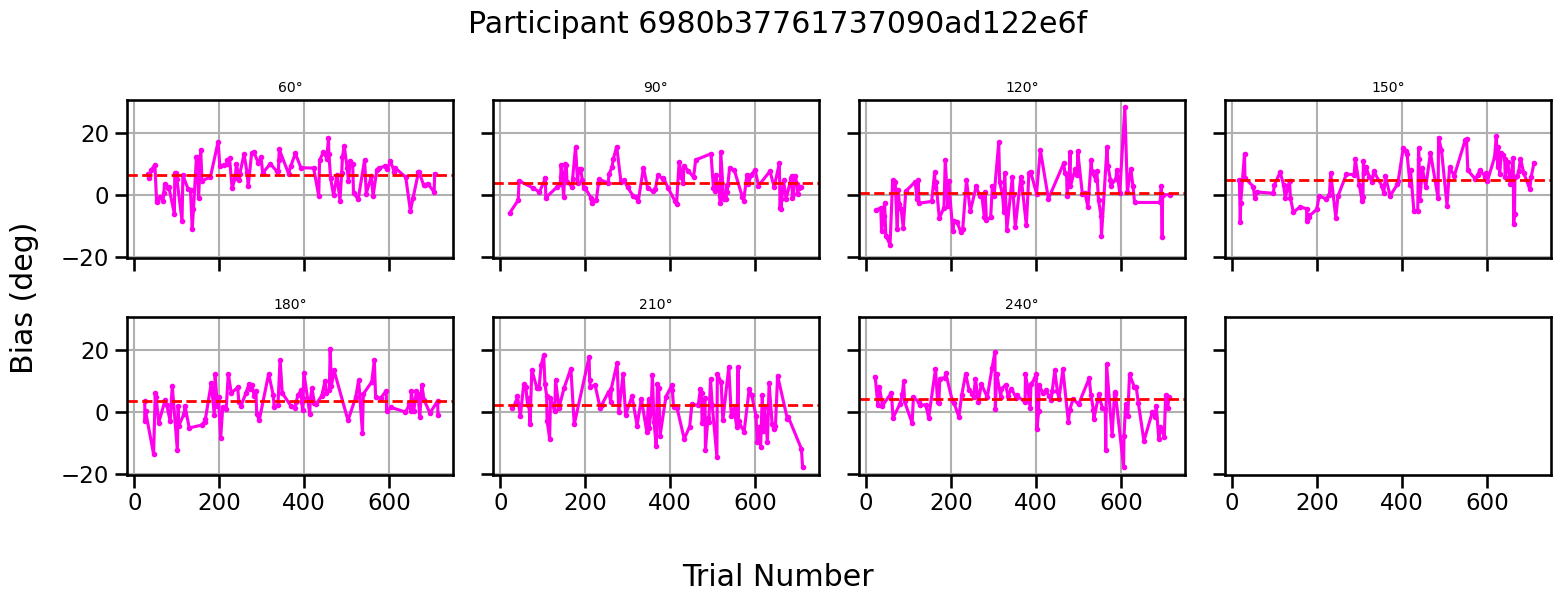

In [21]:
target_angles = sorted(df_repulse["TargetAngle"].unique())

for id in df_repulse["Prolific_ID"].unique():

    ncols = 4
    nrows = int(round(len(target_angles) / ncols, 0))


    fig, axes = plt.subplots(nrows, ncols,figsize=(4*ncols, 3*nrows),sharex=True,sharey=True)

    axes = np.array(axes).flatten()

    for ax, ta in zip(axes, target_angles):

        df_sn = (
            df_repulse[(df_repulse["Prolific_ID"] == id) &(df_repulse["TargetAngle"] == ta)]
            .sort_values("TrialNumber"))

        ax.plot(df_sn["TrialNumber"],df_sn["AngleError"], 'o-', markersize=3)
        mean_val = df_sn["AngleError"].mean()

        ax.axhline(y=mean_val,color='r',linestyle='--',linewidth=2)
        ax.set_title(f"{ta}°", fontsize=10)
        ax.grid(True)

    fig.suptitle(f"Participant {id}")
    fig.supxlabel("Trial Number")
    fig.supylabel("Bias (deg)")
    plt.tight_layout()
    plt.show()